<b><h2> Import required libraries</h2></b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
import kagglehub
from kagglehub import KaggleDatasetAdapter

import warnings
warnings.filterwarnings("ignore")

The very first step of the workflow is that importing all the necessary python libraries required for the data analysis, preprocessing, visualization and machine learning.

Some of the imported libraries are
1. Pandas and Numpy - used for efficient data manipulation and numerical operations
2. Scikit-learn - used for preprocessing, model training, evaluation and hyperparameter tuning.
3. Matplotlib and Seaborn - used for data visualization
4. XGBoost and ensemble methods such as Random Forest and Gradient Boosting are included to evaluate multiple predictive models.

By importing all the necessary libraries at the begining of the workflow will ensure that the environment is fully prepared for the subsequent stages of the machine learning pipeline.


<h3><b>Load dataset</b></h3>

In [2]:
file_path = "house_prices.csv"

In [3]:
data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "alyelbadry/house-pricing-dataset",
  file_path)

100%|██████████| 2.51M/2.51M [00:00<00:00, 181MB/s]


The House Pricing Dataset used in this project is obtained from kaggle which contains information about residential properties and their associated sale prices.

The dataset is loaded using the KaggleHub API, which allows direct access to Kaggle datasets withing the notebook environment. This makes it easy to work as there is no need to download the dataset.

Once the dataset is loaded, it is stored in a Pandas DataFrame called data. This enables efficient data manipulation and analysis throughout the project.

<h3><b>Basic overview of the dataset</b></h3>

In [4]:
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
print("Dataset shape", (data.shape))

Dataset shape (21613, 21)


Initial exploration of the dataset is conducted to understand its structure and characteristics.

Thr .head() function is used to have a quick preview of the available features and data in the dataset.

The dataset contains 21 columns and 21,613 rows, representing various property attributes such as:

* number of bedrooms and bathrooms

* property size in square feet

* construction year

* geographical coordinates

* overall condition and grade

This step helps establish an understanding of the available features before performing further analysis.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  object 
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  object 
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

The .info() function is used to inspect the dataset's structure in more detail, including:

* the number of non-null values for each column

* the data types of each feature

* the total memory usage of the dataset

From this analysis, it is clear that this dataset contains both numerical and categorical variables, including object-type features such as waterfront and condition.

These categorical variables will require encoding before they can be used in machine learning models.

In [7]:
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.234303,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.766318,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,4.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


The .describe() function is used to generate and inspect a statistical overview of the numerical features within the dataset.

This includes metrics such as:

* mean

* standard deviation

* minimum and maximum values

* quartiles (25%, 50%, 75%)

For example, the mean of the no of bathrooms is 3.37, the standard deviation of sqft_living column is 918.44.

These statistics provide insights into the distribution and range of each feature, helping identify potential outliers and unusual values within the dataset.

<h3><b>Checking for null values in the dataset</b></h3>

In [8]:
data.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


Data quality is an important aspect of machine learning projects.

The dataset is checked for missing values using the .isnull().sum() method.

The results show that no missing values are present, meaning no additional imputation or data cleaning is required at this stage.

<h3><b>Checking for duplicated values in the dataset</b></h3>

In [9]:
data.duplicated().sum()

np.int64(0)

Duplicate records can negatively impact model performance by introducing bias and redundancy.

The dataset is checked for duplicate entries using .duplicated().sum().

The analysis confirms that no duplicate rows are present, ensuring the dataset is clean and suitable for training machine learning models.

<h3><b>Dropping irrelavent columns</b></h3>

In [10]:
data = data.drop('id', axis=1)
data = data.drop('date', axis=1)

Certain columns in the dataset are dropped because they do not contribute meaningful information for predicting house prices.

1. id represents a unique identifier for each property and does not contain predictive information.

2. date represents the sale date but is not relevant for this predictive task in its current format.

Removing these columns simplifies the dataset and helps prevent unnecessary noise in the model.

<h3><b>Encode categorical features</b></h3>

In [11]:
condition_order = ['Poor', 'Fair', 'Average', 'Good', 'Very Good']
encoder = OrdinalEncoder(categories=[condition_order])

data['condition'] = encoder.fit_transform(data[['condition']])

In [12]:
waterfront_order = ['N', 'Y']
encoder = OrdinalEncoder(categories=[waterfront_order])

data['waterfront'] = encoder.fit_transform(data[['waterfront']])

Machine learning algorithms require numerical inputs, so categorical variables must be converted into numeric representations.

As we discovered earlier, there are two categorical features present in the dataset:

1. condition – representing the quality of the property condition

2. waterfront – indicating whether the property is located on a waterfront

These features are encoded using Ordinal Encoding, which converts categorical labels into ordered numeric values while preserving their logical ranking.

Target Variable Analysis (House Prices)

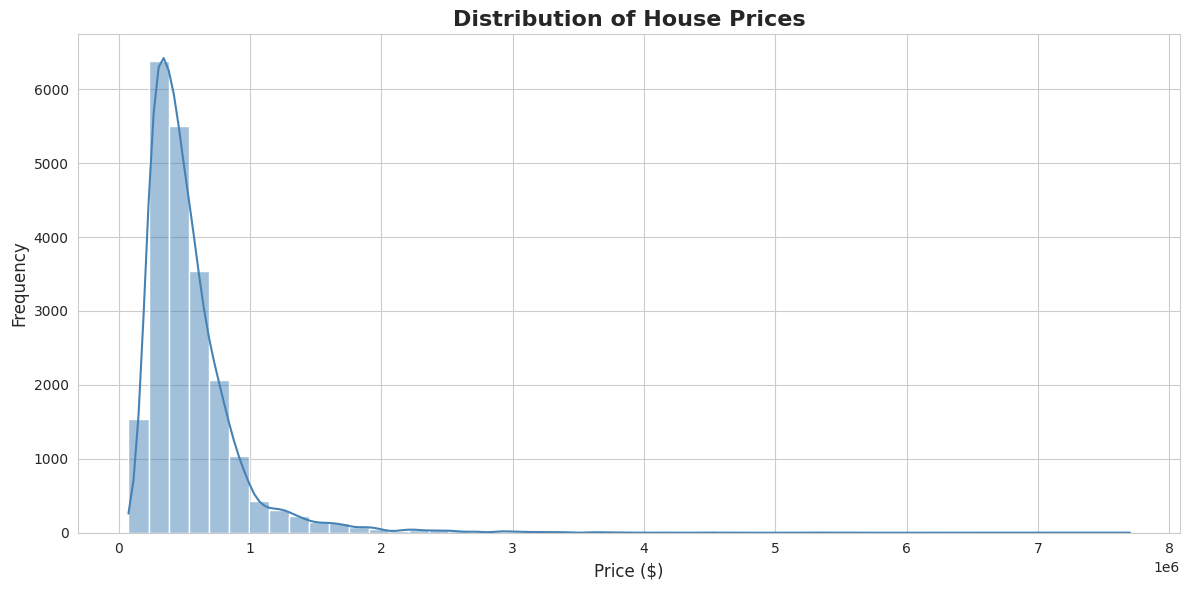

In [13]:
sns.set_style("whitegrid")
sns.set_palette("husl")

plt.figure(figsize=(12, 6))
sns.histplot(data["price"], bins=50, kde=True, color='steelblue')
plt.title("Distribution of House Prices", fontsize=16, fontweight='bold')
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

Understanding the distribution of the target variable (price) is essential before building predictive models.

A histogram with a kernel density estimate (KDE) is used to visualize the distribution of house prices (in USD).

The distribution shows that house prices are positively skewed, meaning a large number of properties fall within lower price ranges while a smaller number of properties have extremely high prices.

A boxplot is also used to identify potential outliers in the price distribution.
As we can see in the boxplot, there is a higher number of outliers present within this dataset which are represented by the dots outside the whisker of the boxplot.

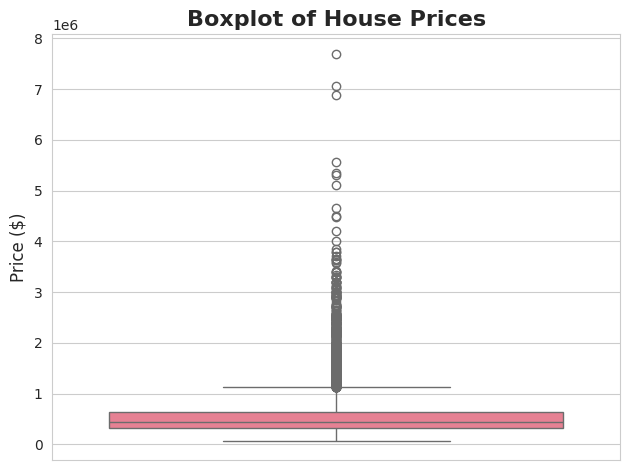

In [14]:
sns.boxplot(y=data['price'])
plt.title('Boxplot of House Prices', fontsize=16, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12)

plt.tight_layout()
plt.show()

In [15]:
skewness = data['price'].skew()
print(f"Skewness: {skewness:.3f}")

Skewness: 4.024


The skewness of the price distribution is calculated to quantify the degree of asymmetry.

The skewness value of 4.024 indicates a strong positive skew, meaning the dataset contains several high-value properties that significantly exceed the average price.

Such skewness is common in real estate datasets and may influence model performance

<h3><b>Correlation heatmap</b></h3>

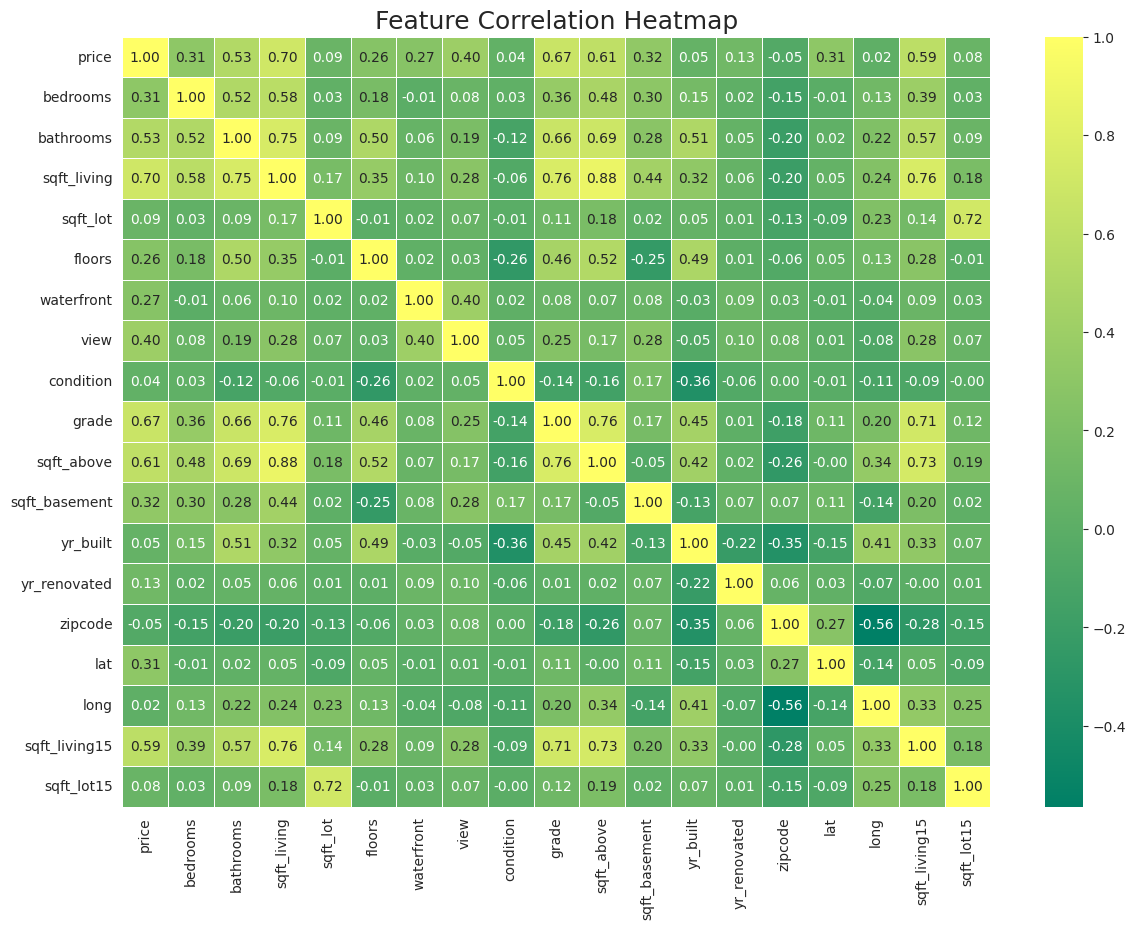

In [16]:
plt.figure(figsize=(14,10))

correlation = data.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="summer",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=18)
plt.show()

A correlation heatmap is used to visualize the relationships between numerical features in the dataset.

This analysis helps identify features that are strongly associated with house prices.

Key observations include:

* sqft_living has the strongest positive correlation with price which is 0.70.

* grade (0.67) and sqft_above (0.61) also show strong relationships with house prices.

* Geographic features such as longitude (0.02), zipcode (-0.05) and year built (0.05) show weak correlation with the house prices.

Understanding these relationships helps guide feature selection and model development

In [17]:
data.corr()["price"].sort_values(ascending=False)

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
bathrooms,0.525138
view,0.397293
sqft_basement,0.323816
bedrooms,0.308350
lat,0.307003


<h3><b>Feature distribution plots</b></h3>

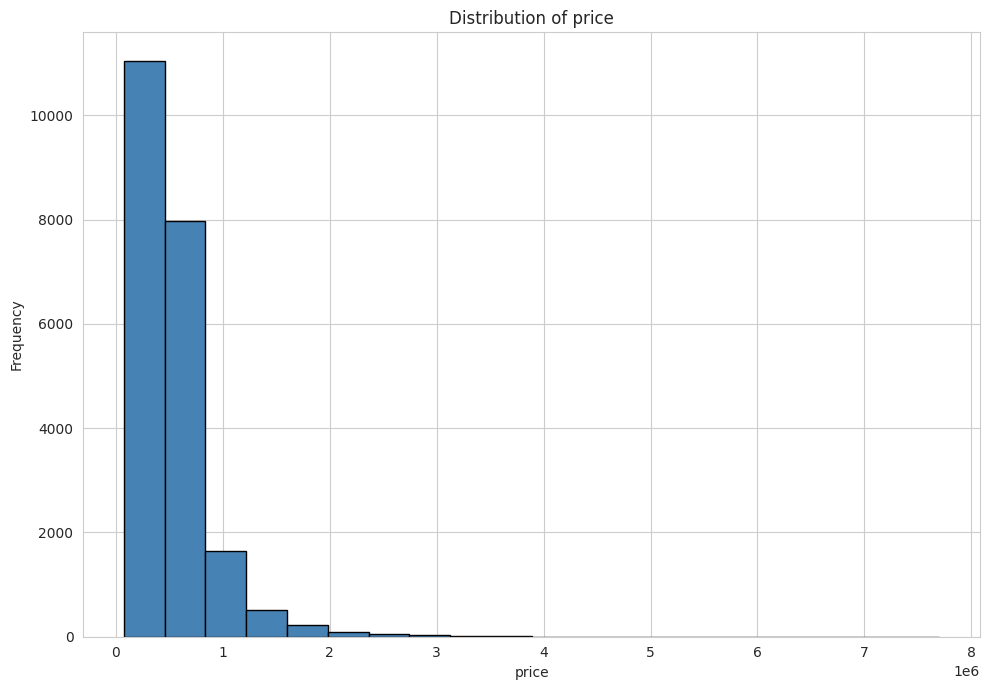

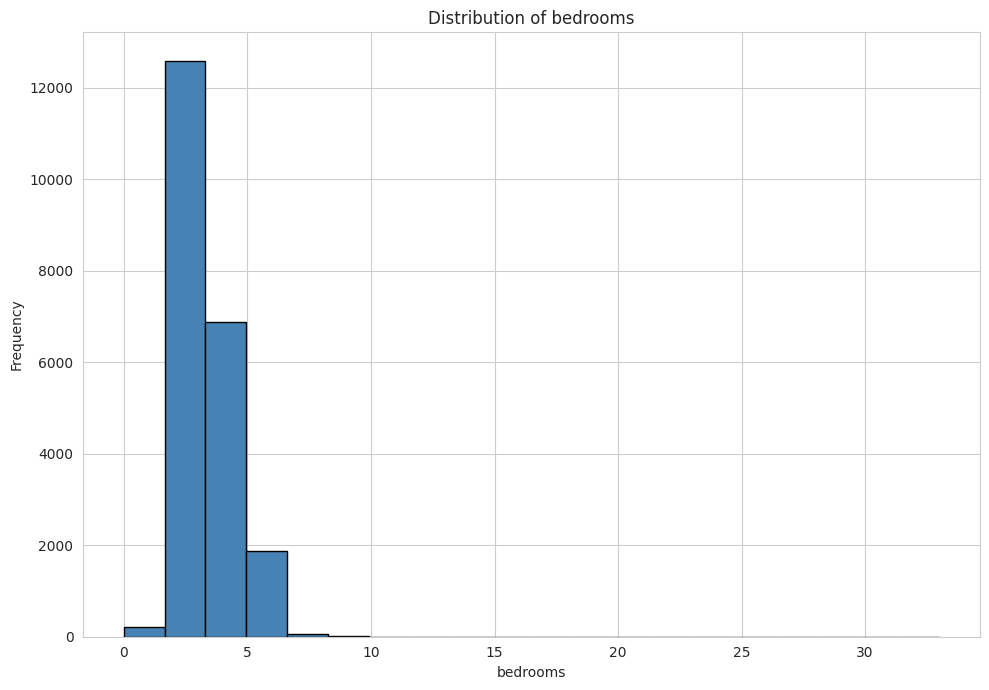

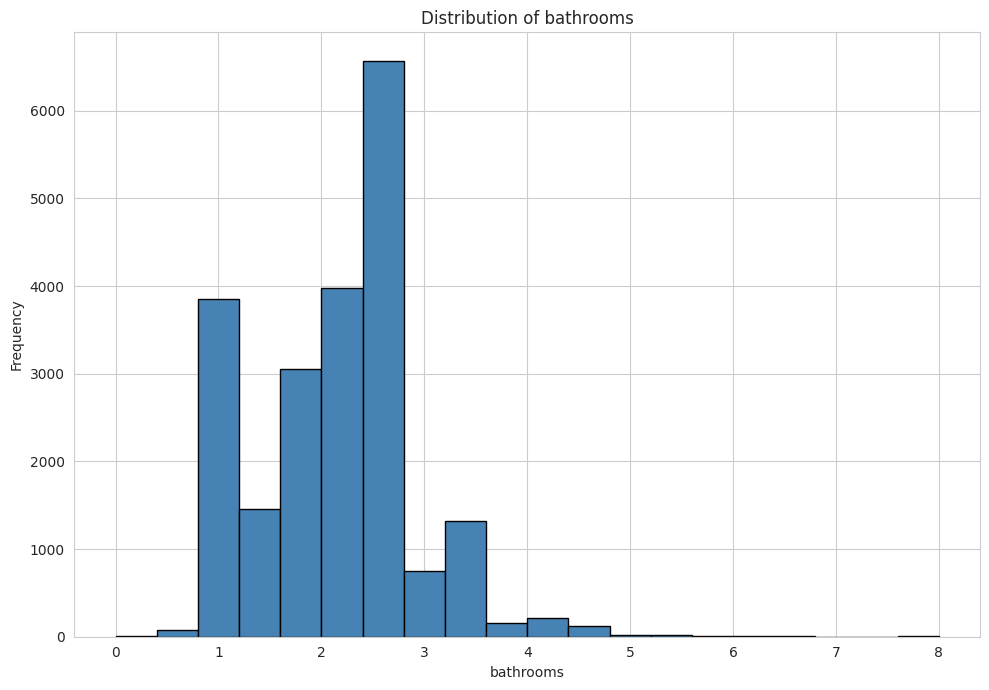

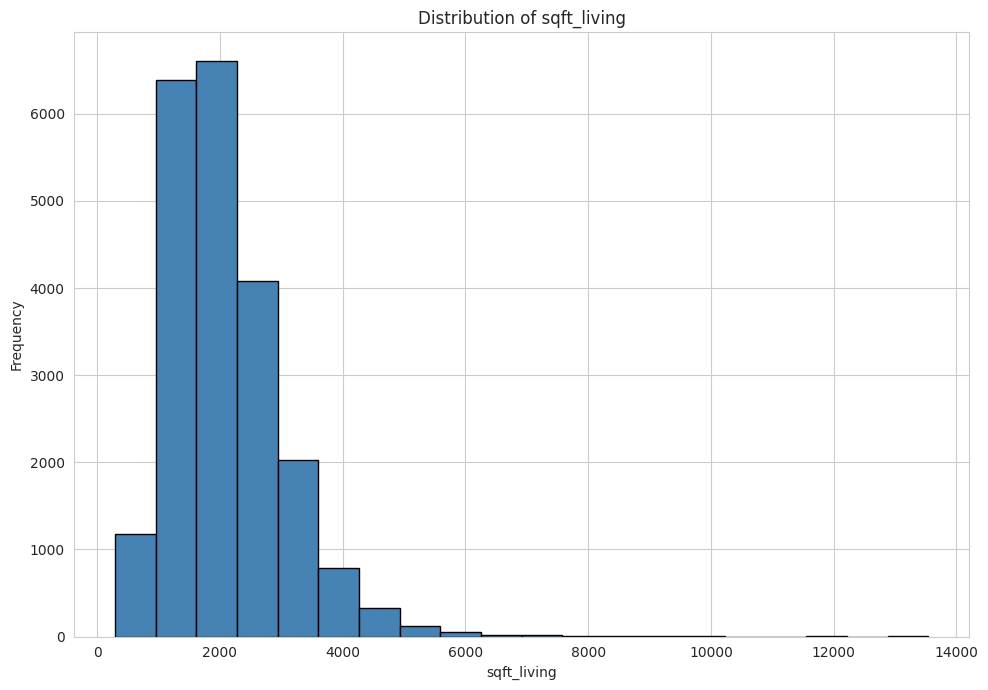

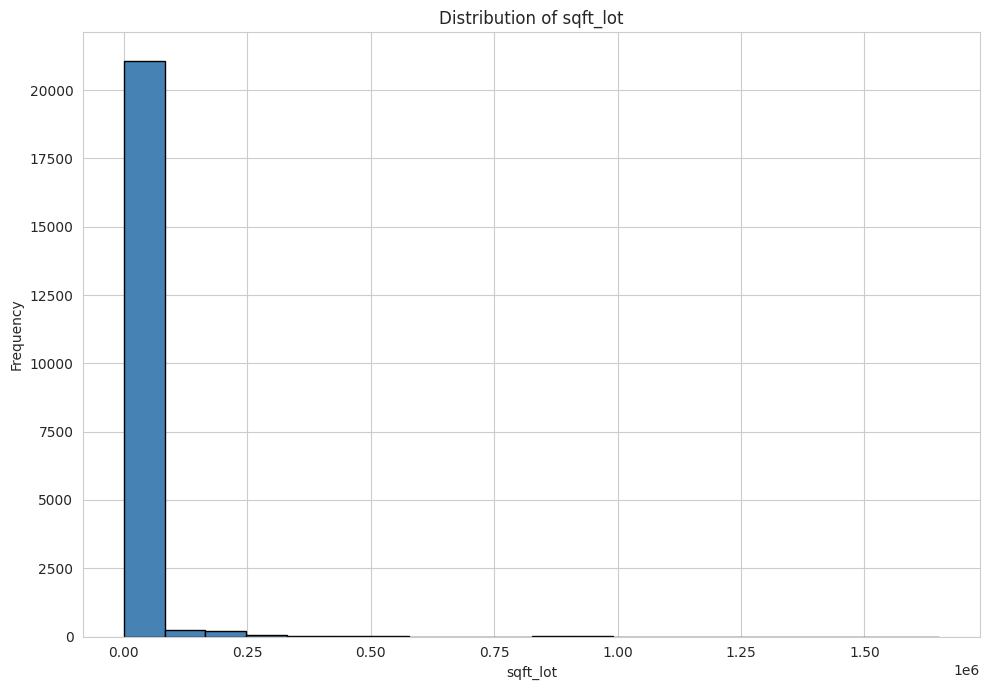

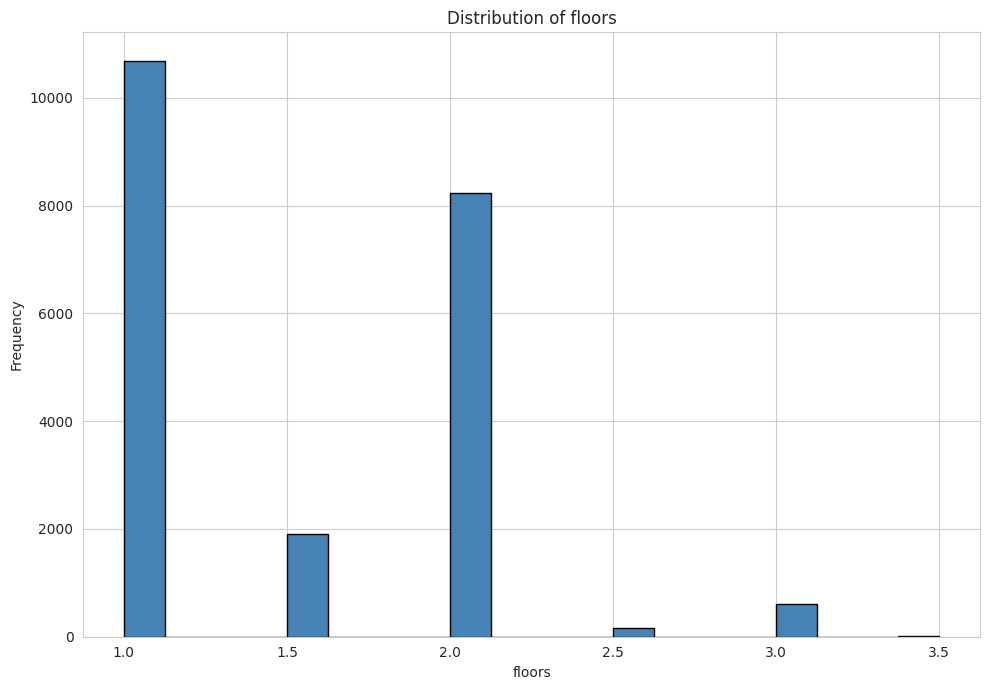

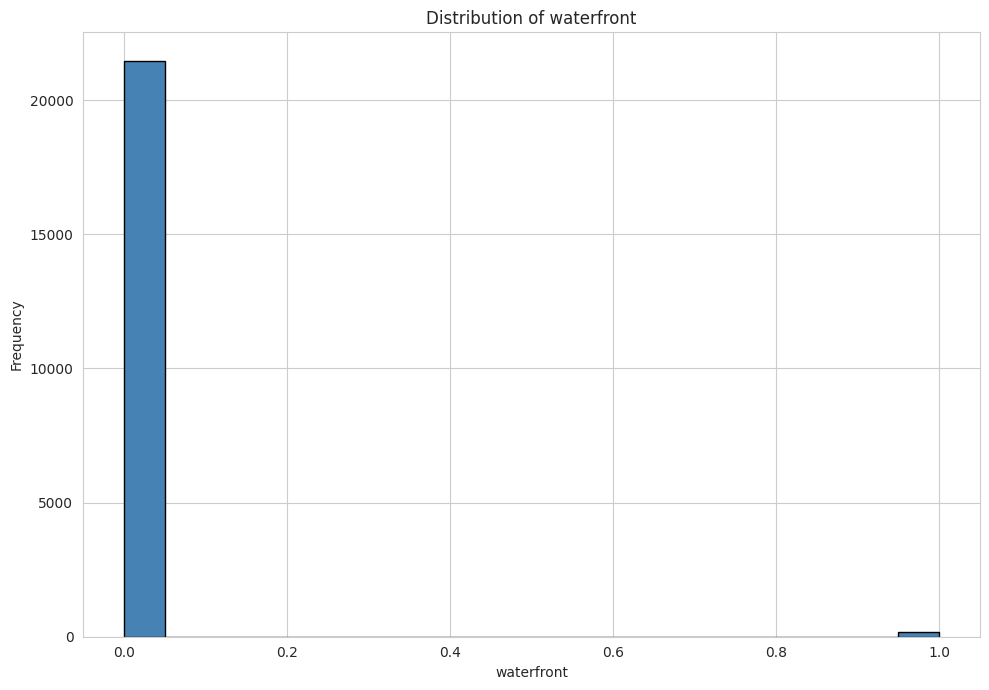

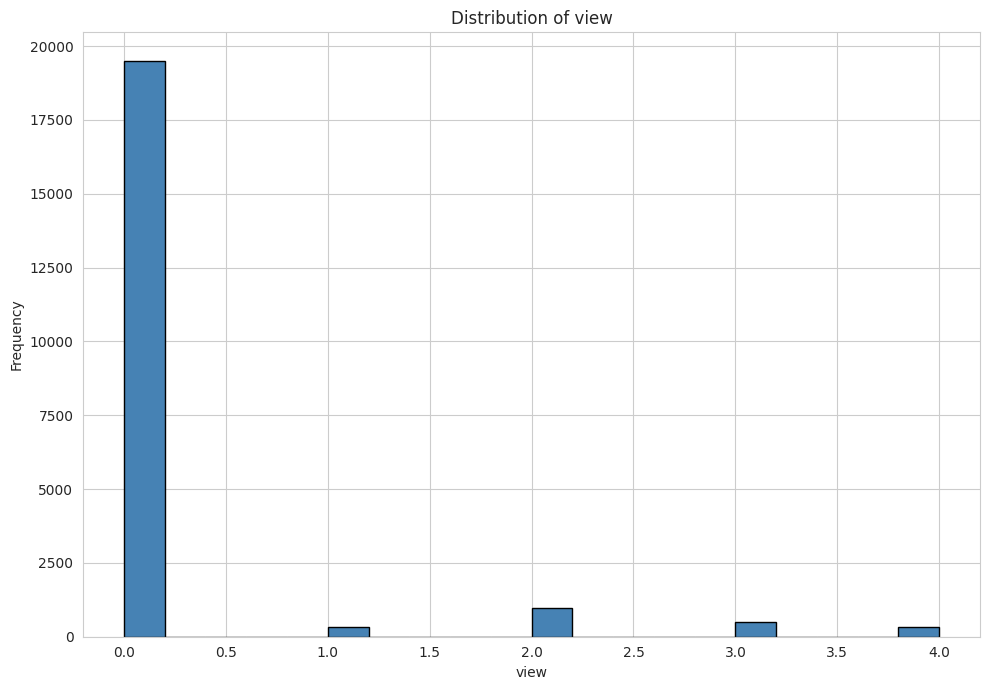

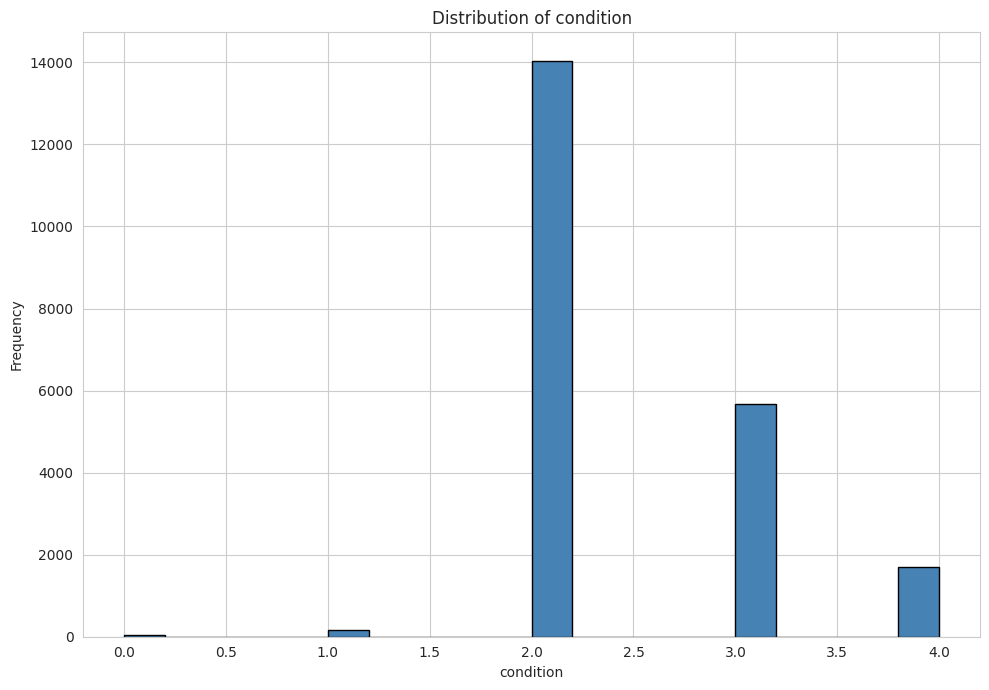

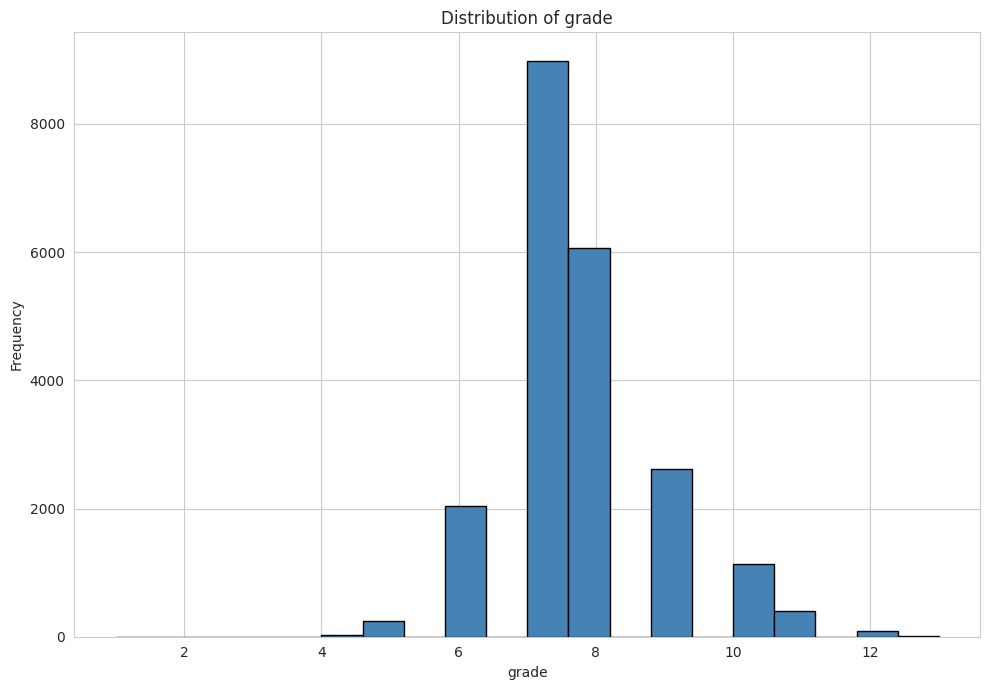

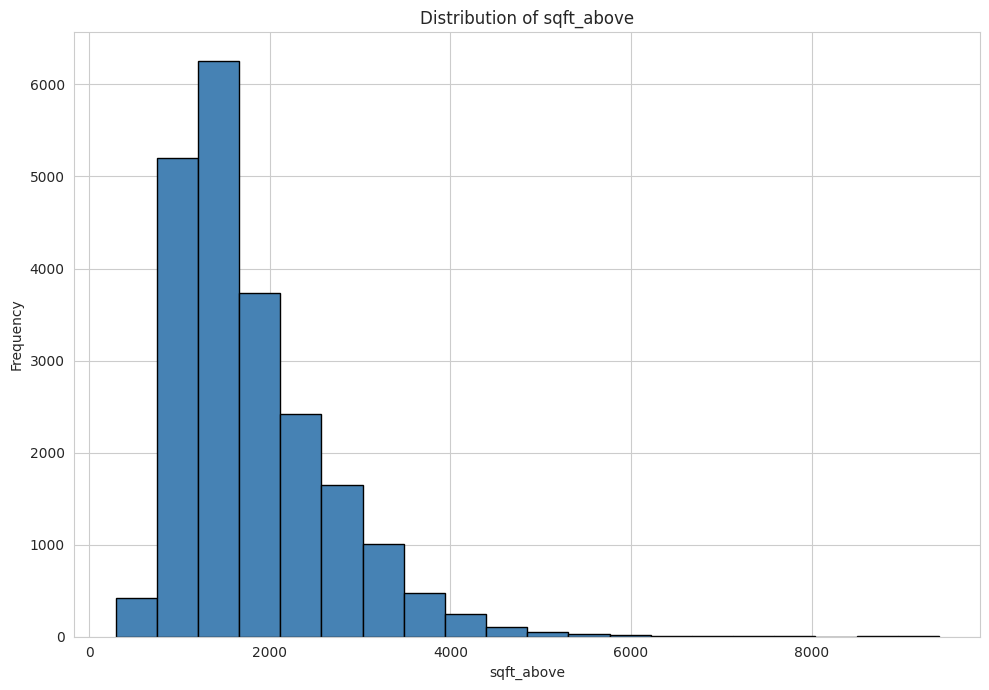

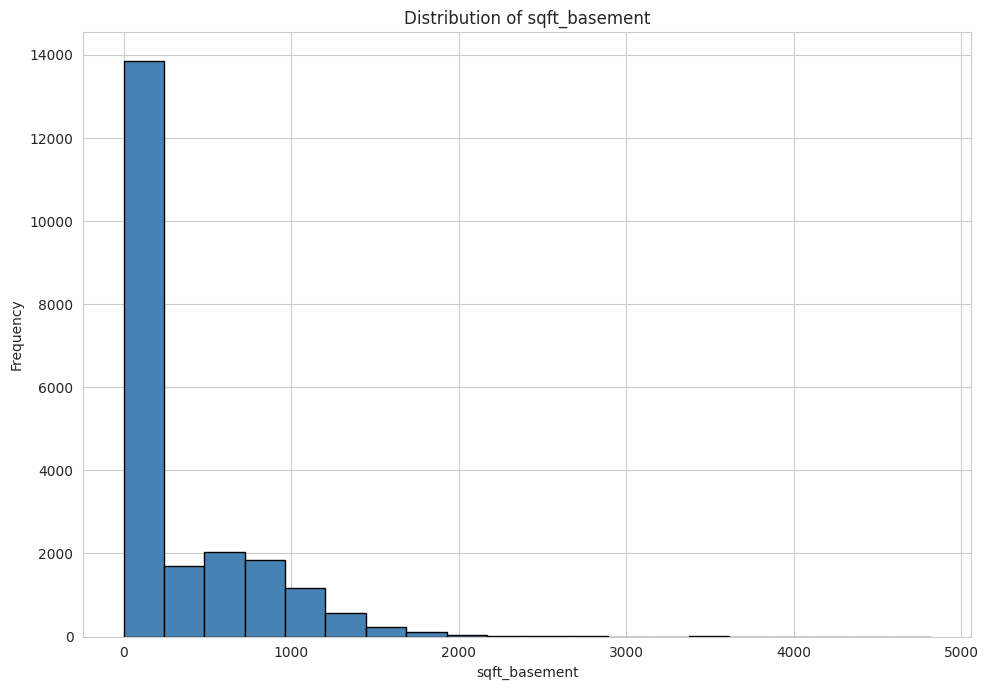

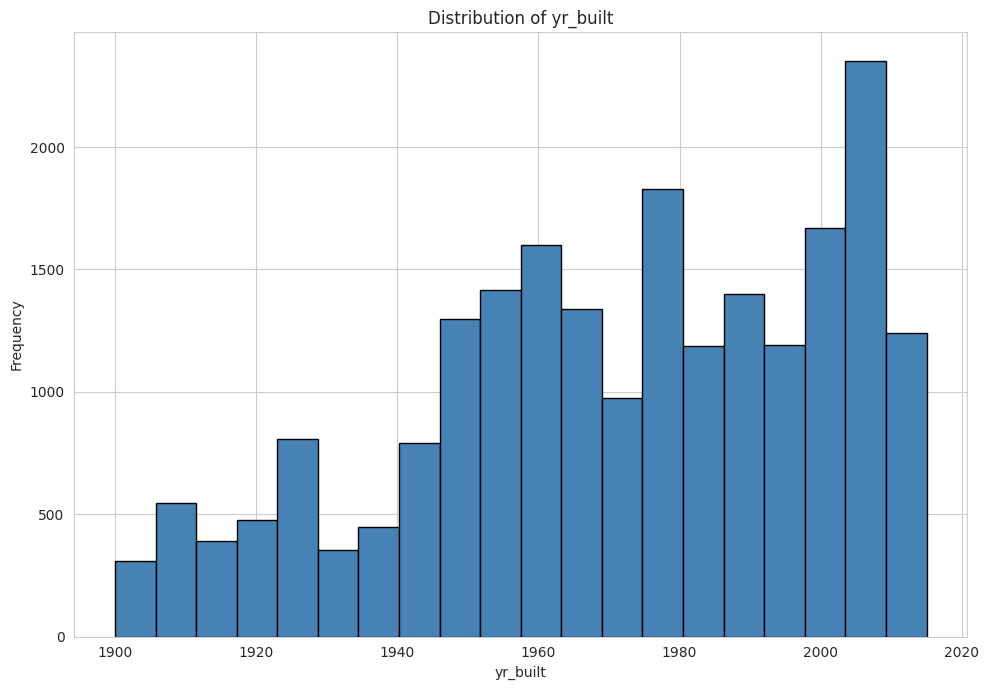

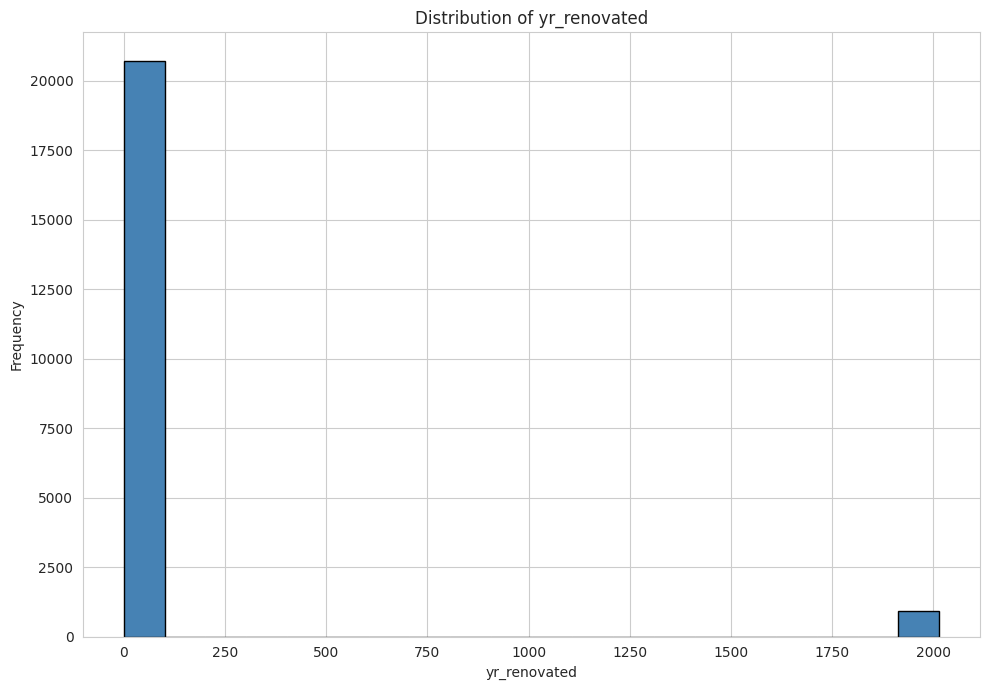

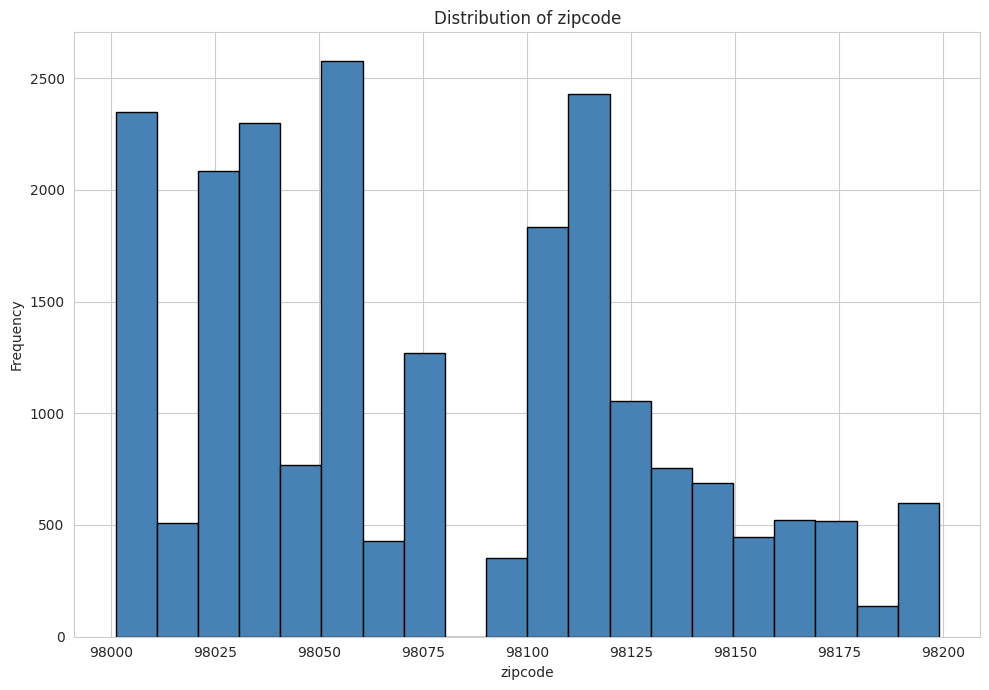

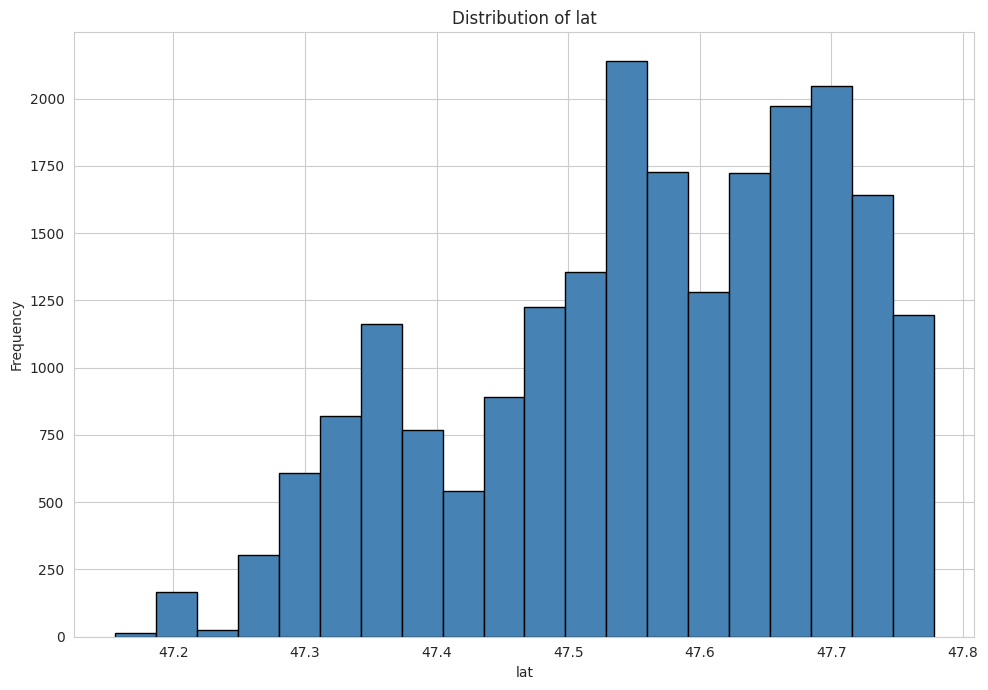

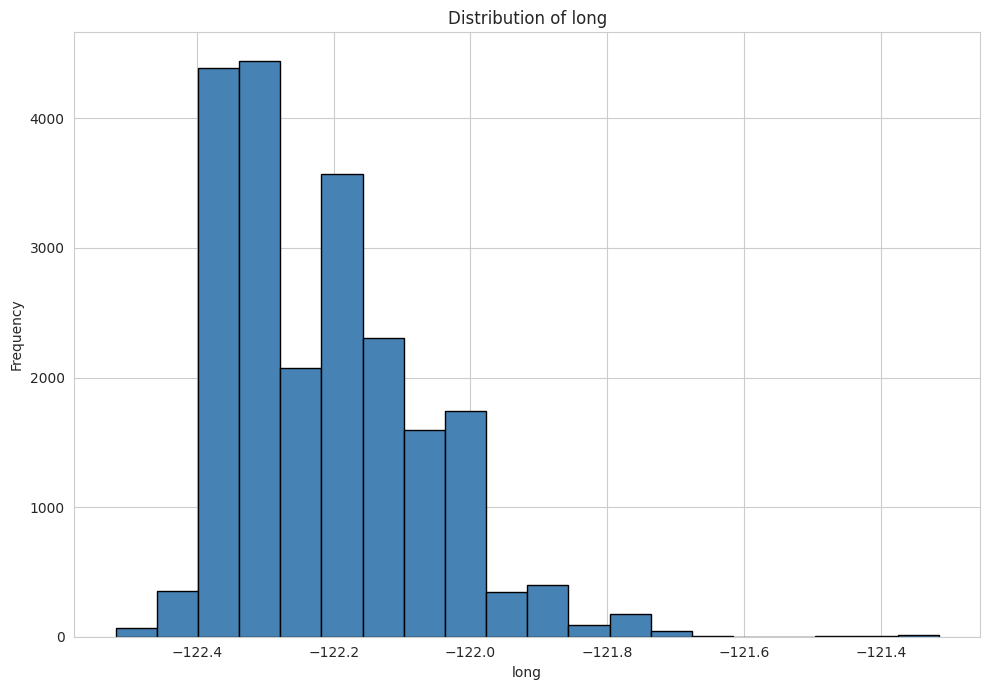

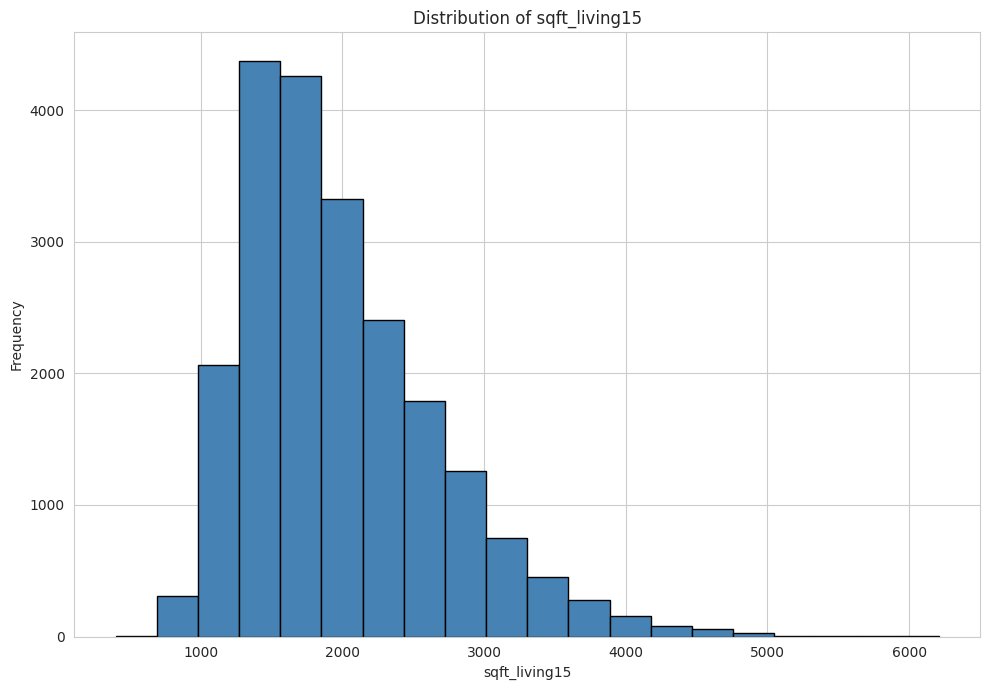

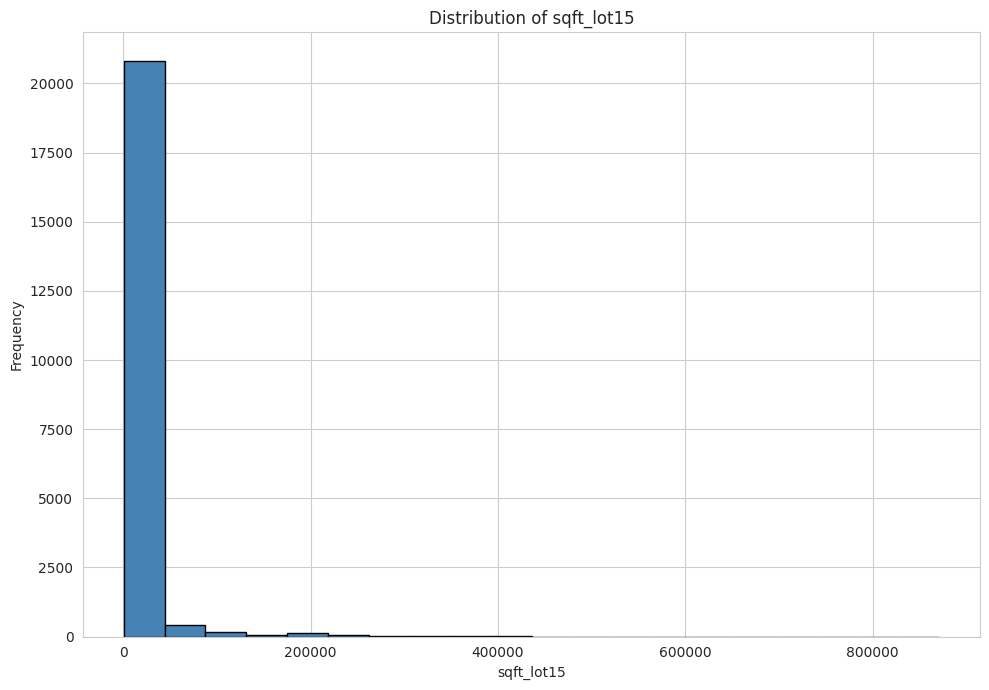

In [18]:
for column in data.select_dtypes(include=['int64', 'float64']).columns:
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    plt.figure(figsize=(10, 7))
    plt.hist(data[column], bins=20, edgecolor='black', color='steelblue')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

Histograms are generated for each numerical feature to examine their distributions.

This analysis helps identify:

* skewed variables (features such as sqft_living, sqft_above positiively skewed, on the other hand features such as year built, latitude are negativly skewed.)

* potential outliers (in features such as no of bathrooms, sqft_lot)

* unusual value ranges

Understanding feature distributions is important because machine learning models can behave differently depending on how input features are distributed.

<h3><b>Feature vs House Price relationships </b></h3>

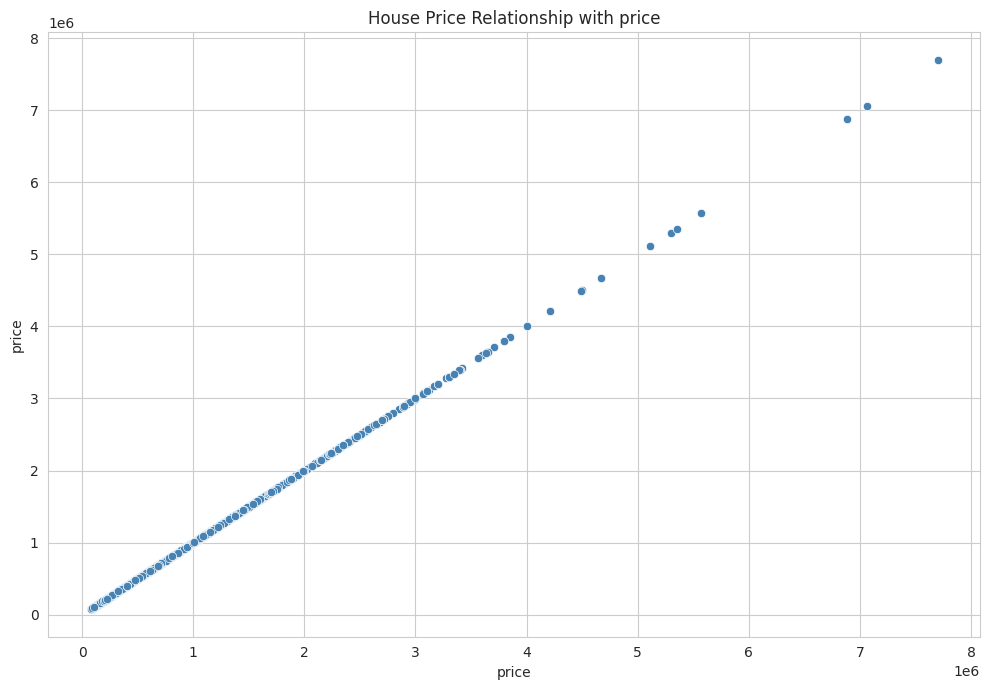

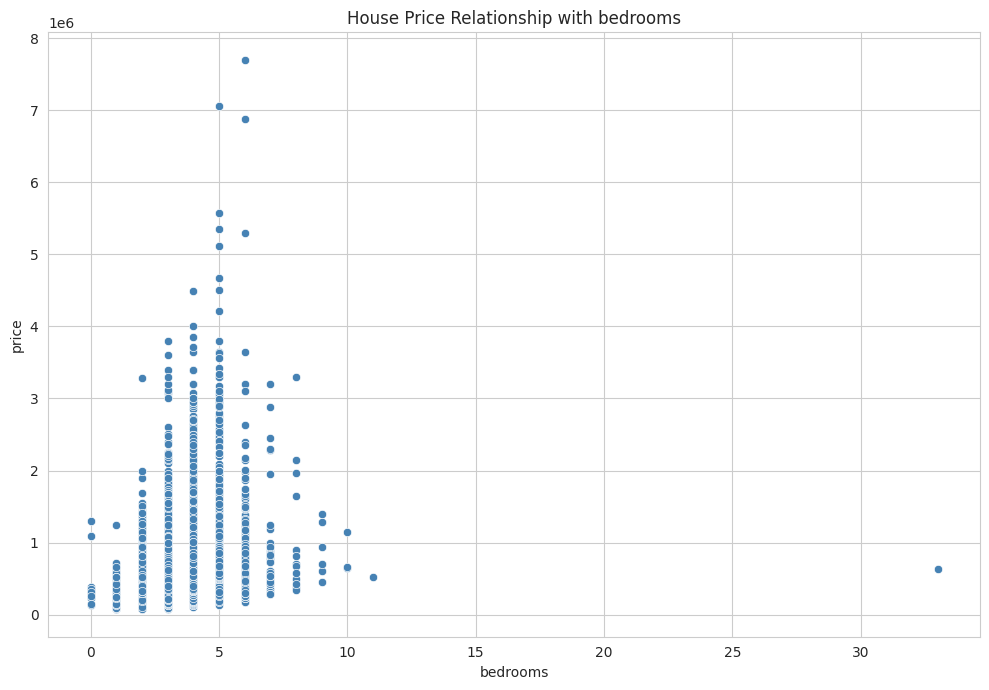

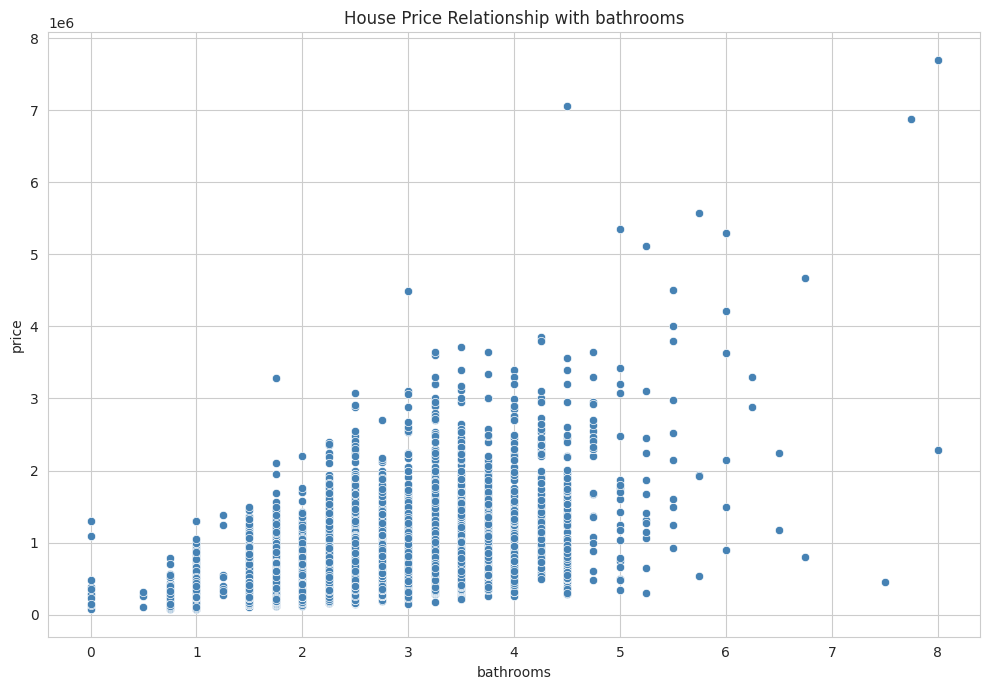

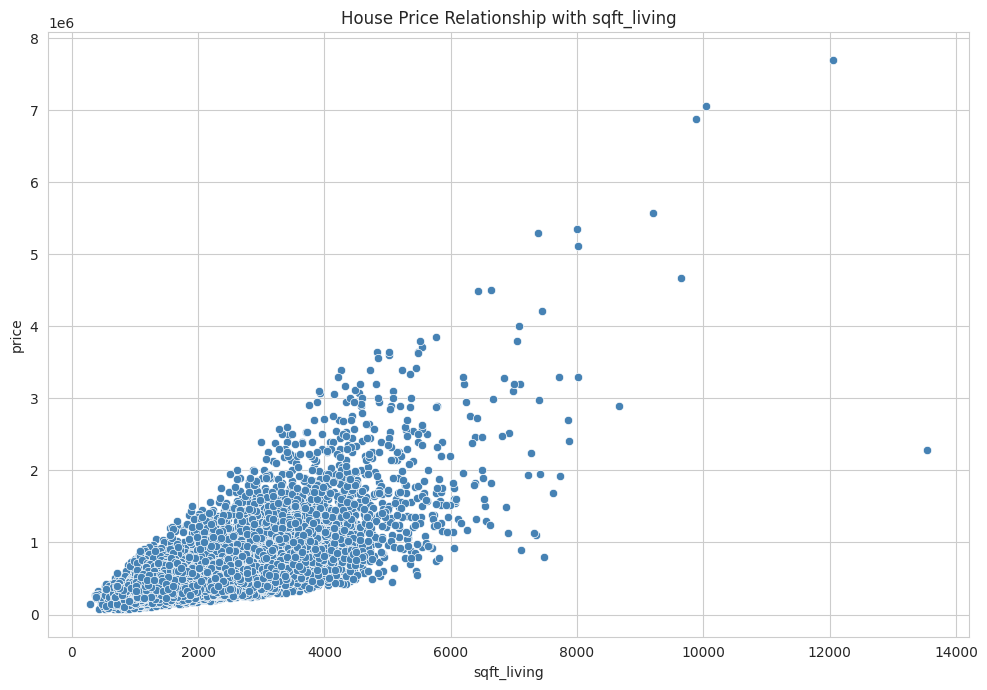

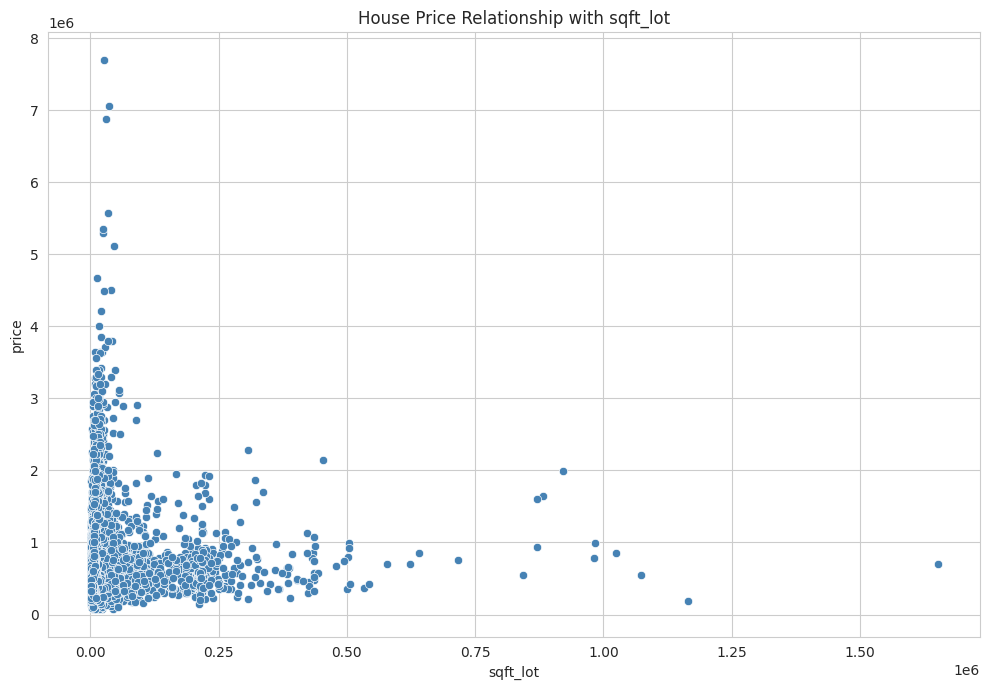

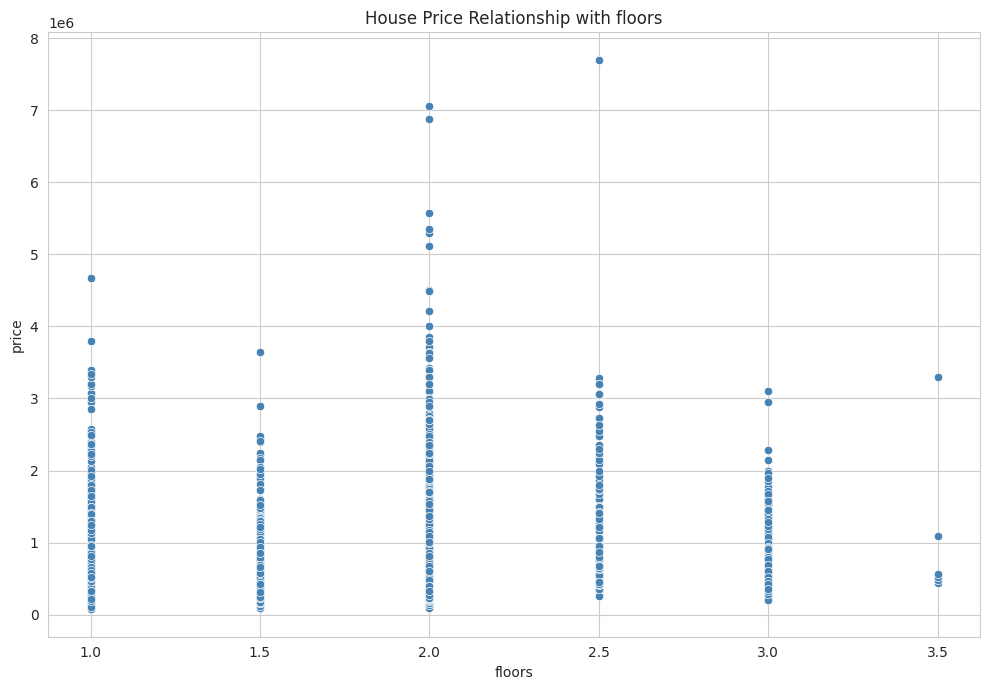

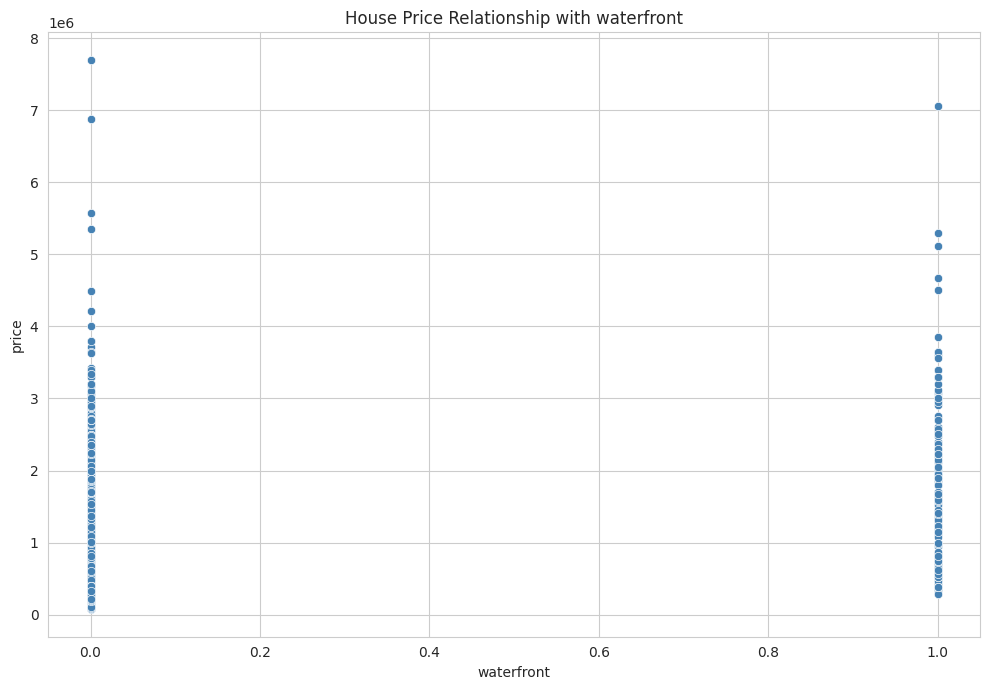

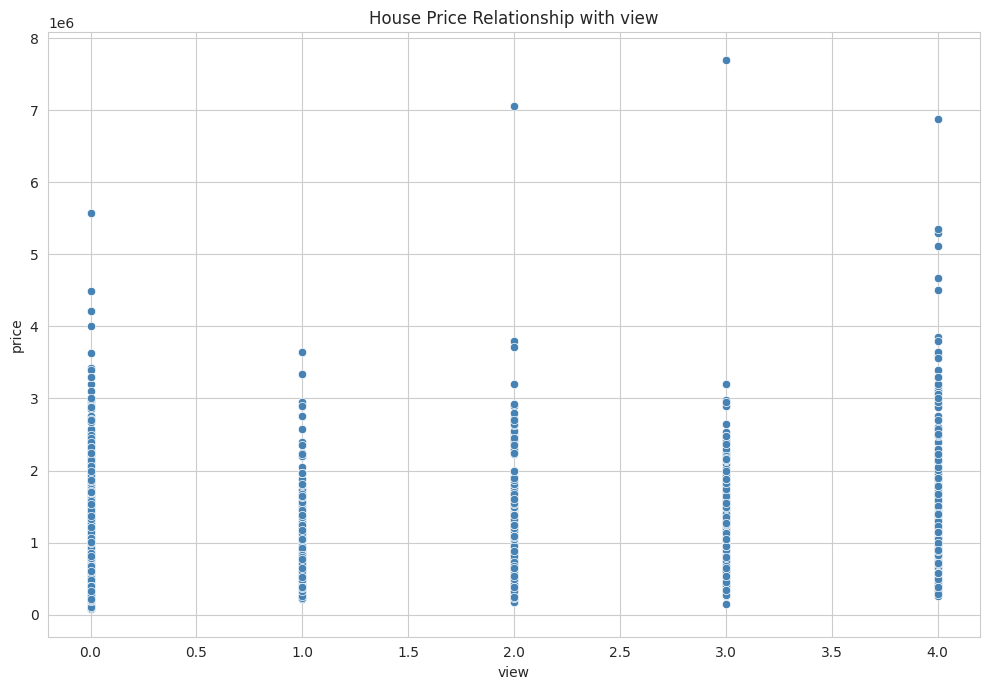

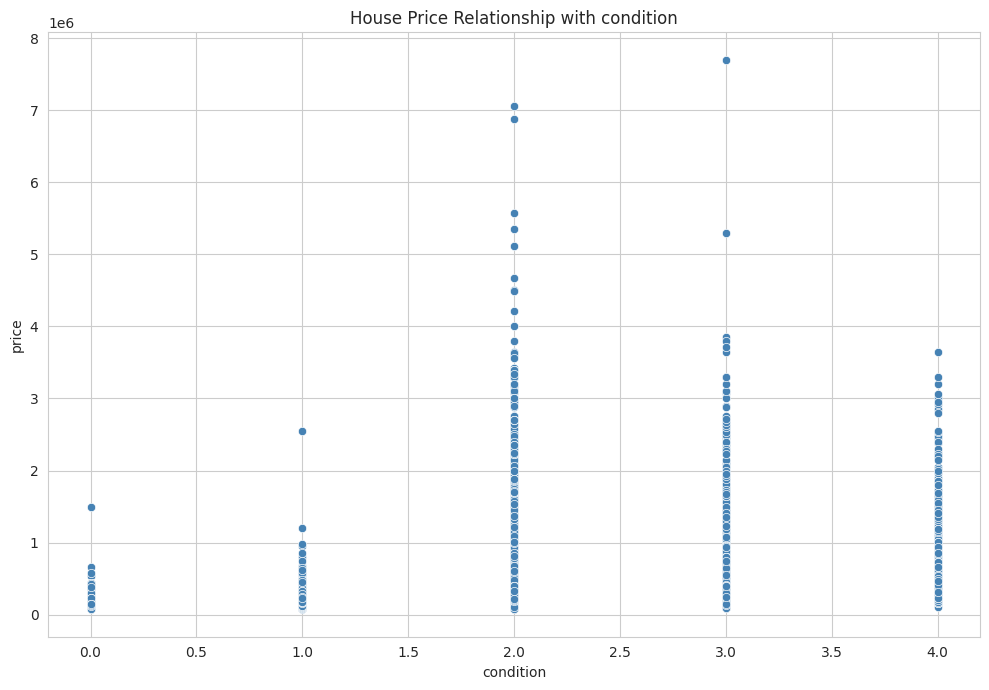

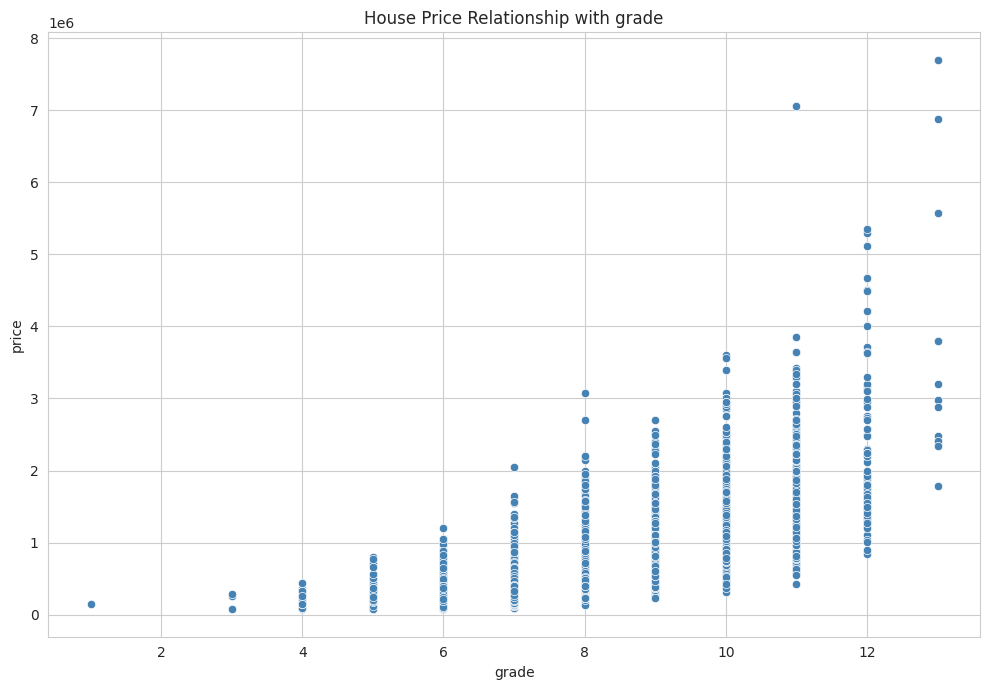

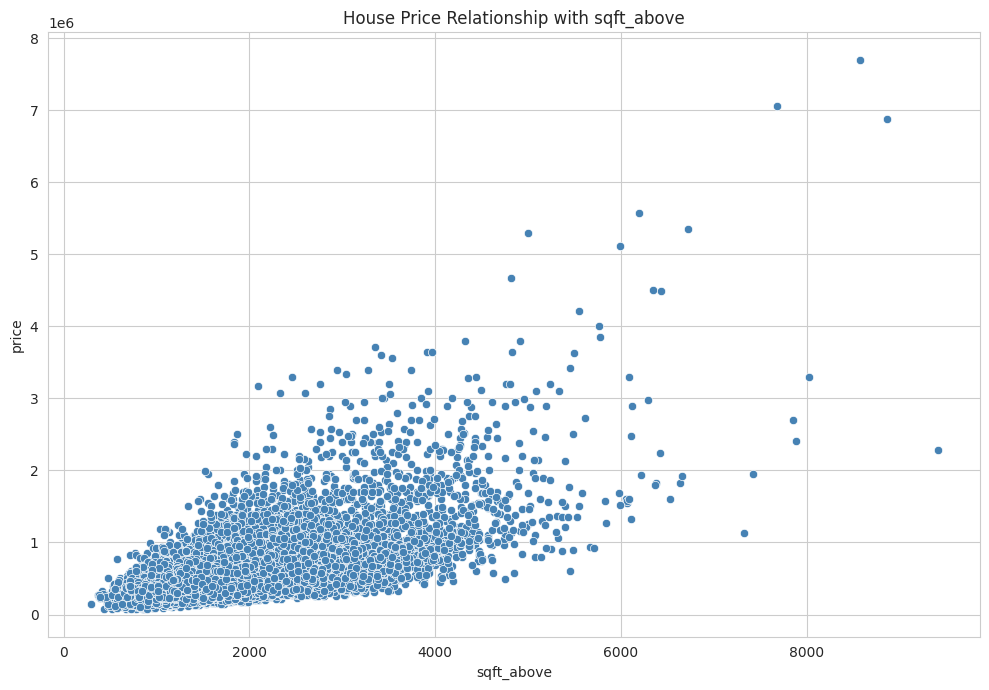

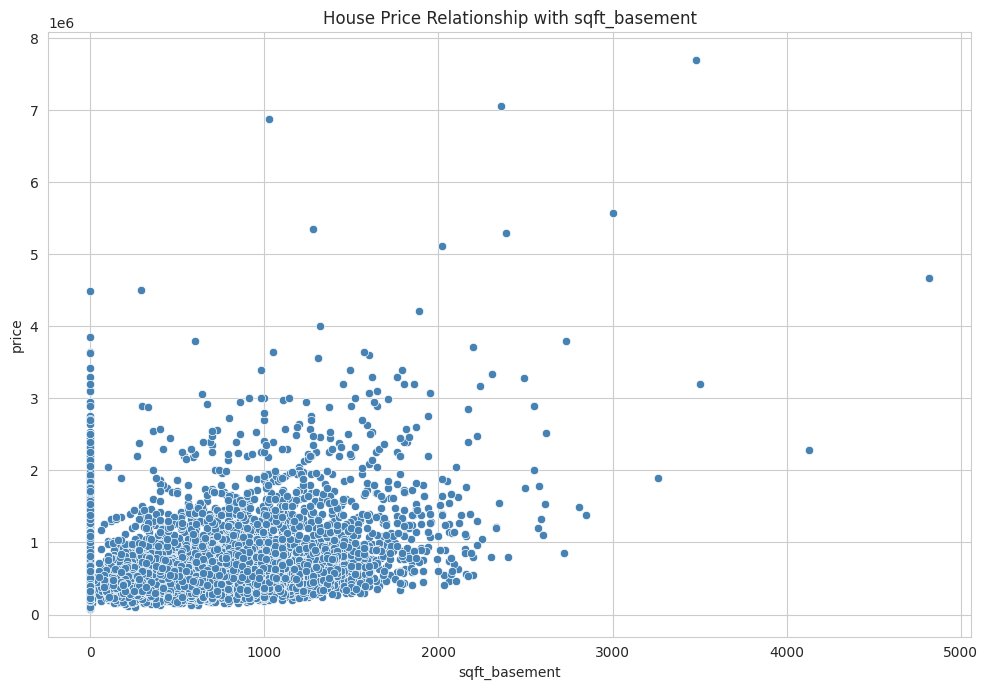

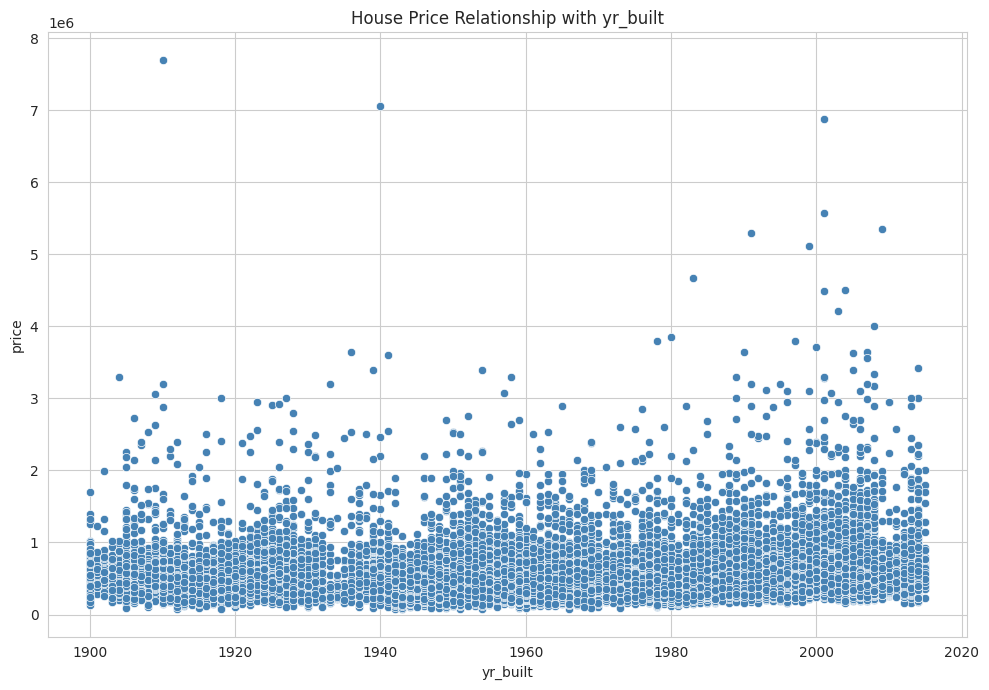

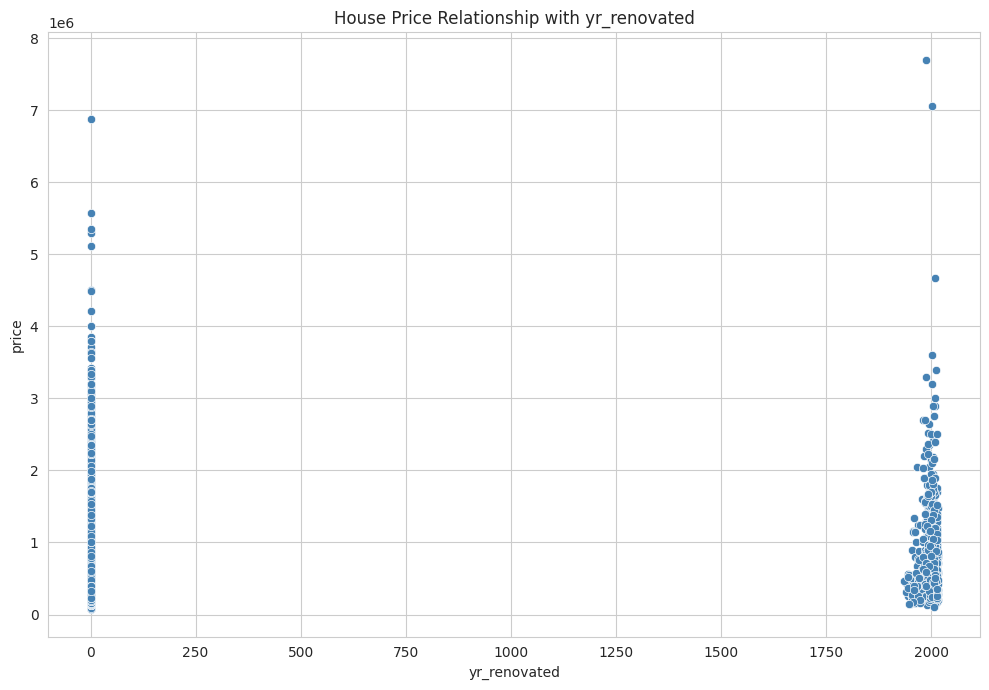

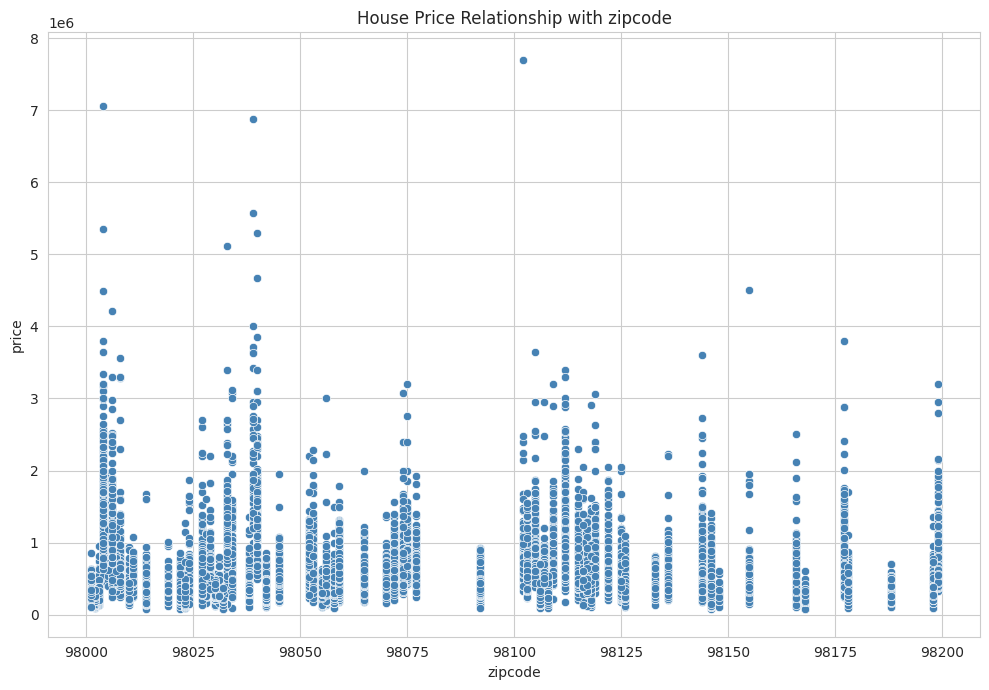

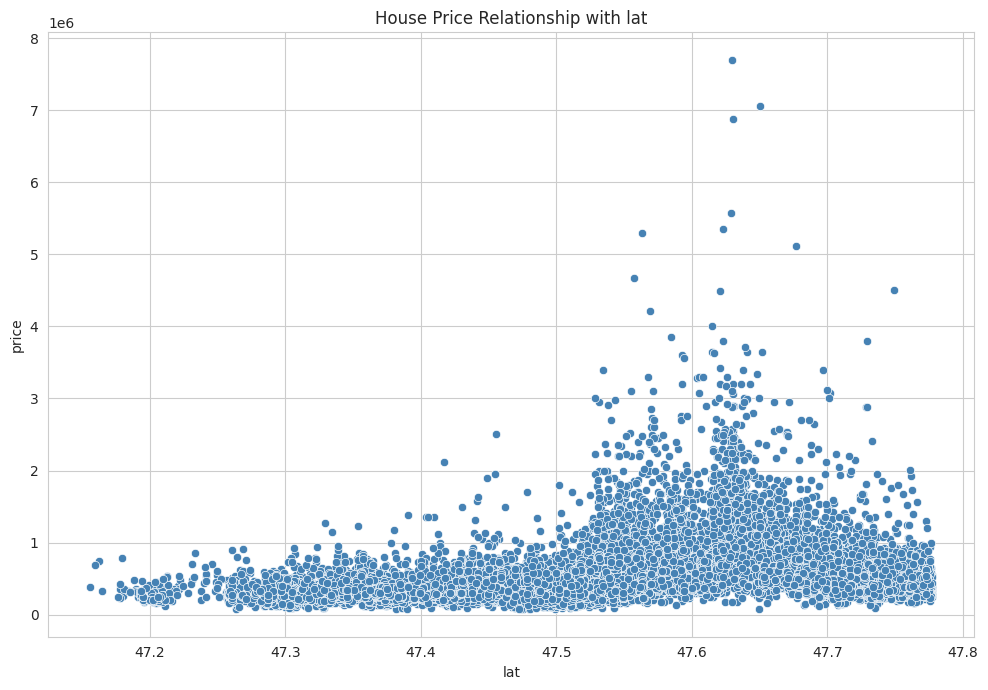

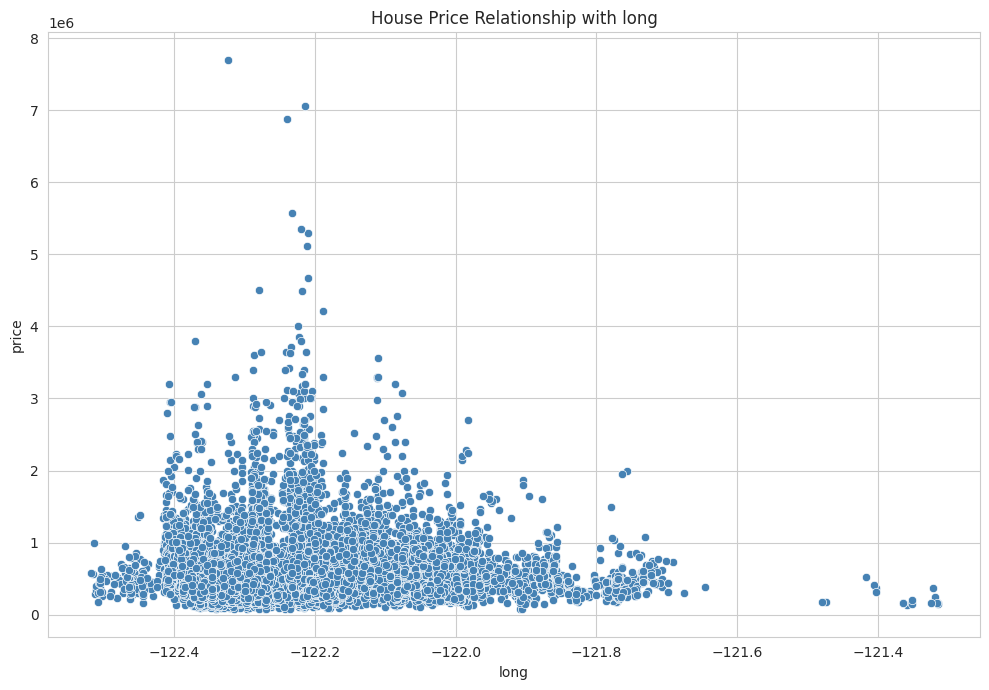

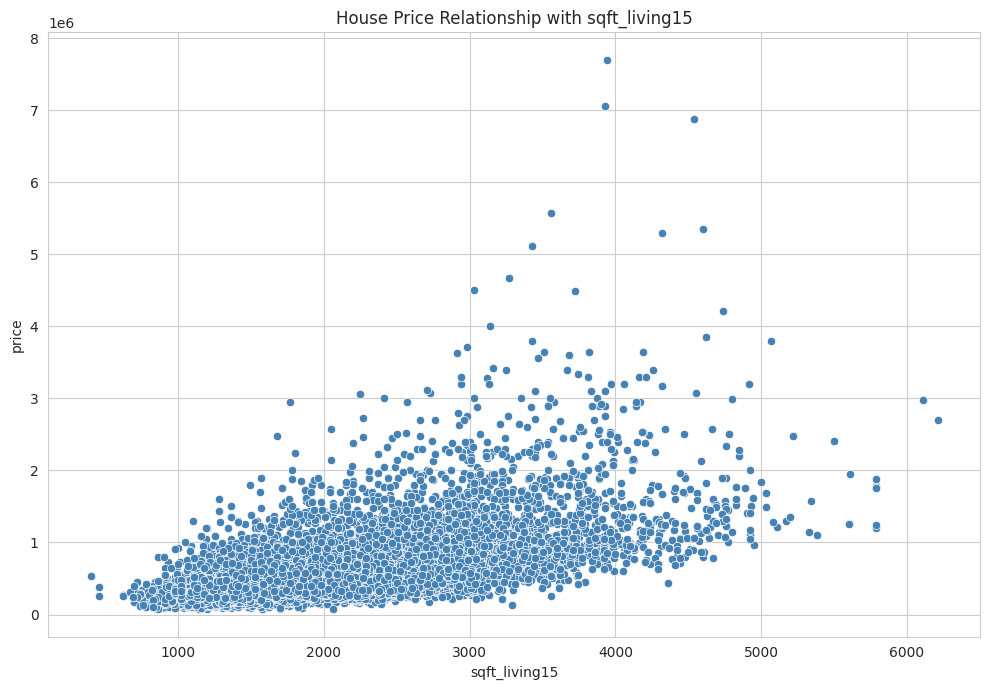

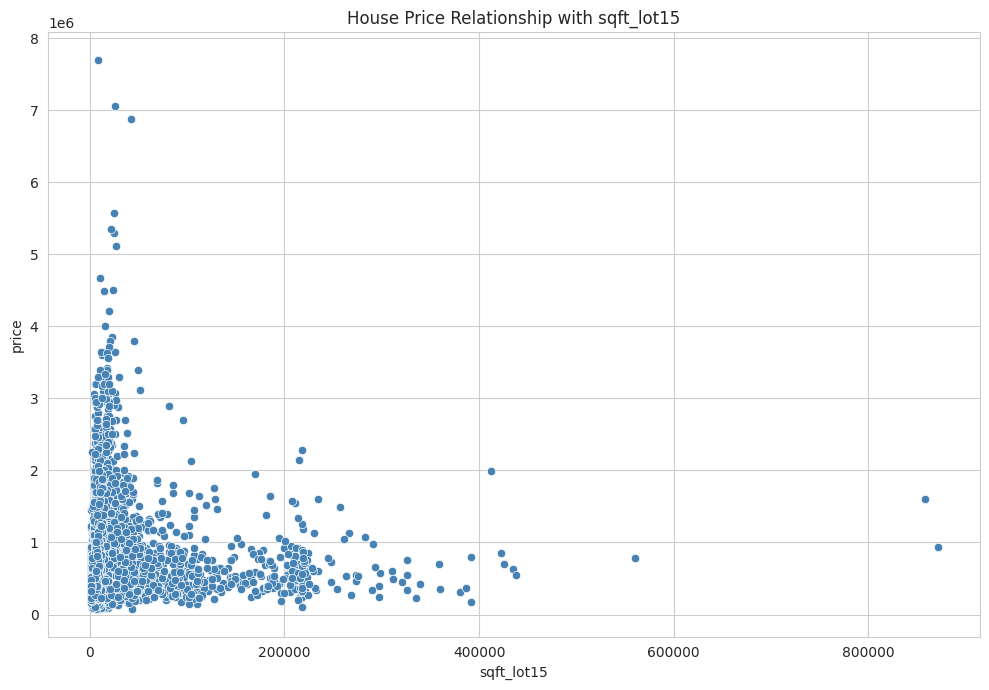

In [19]:
for column in data.select_dtypes(include=['int64', 'float64']).columns:
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=data[column], y="price", data=data, color="steelblue")
    plt.title(f'House Price Relationship with {column}')
    plt.xlabel(column)
    plt.ylabel('price')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

To further understand how individual housing attributes influence property prices, scatter plots were generated to visualize the relationship between each numerical feature and the target variable (house price).

Each plot displays:

* X-axis: feature value (e.g., sqft_living, bedrooms, bathrooms)

* Y-axis: house price

These visualizations help identify:

* positive or negative correlations (sqft_living showed a strong positive relationship)

* nonlinear relationships (such as latitiude)

* potential outliers

* features with stronger predictive influence


By examining these scatter plots, we gain intuitive insight into the underlying relationships within the dataset, which supports better feature selection and model development.

<h3><b>Feature Selection </b></h3>

In [ ]:
features = ["bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","condition","grade","sqft_above","sqft_basement","yr_built","yr_renovated","zipcode","lat","long","sqft_living15", "sqft_lot15"]

Feature Selection explanation

Feature selection is the process of identifying the most relevant variables that contribute to predicting the target variable—in this case, house prices.

The goal of feature selection is to:

* improve model performance

* reduce model complexity

* eliminate irrelevant or redundant variables

* prevent overfitting

In this project, the following steps were used to guide feature selection:

1. Correlation Analysis - The correlation heatmap was used to evaluate the relationship between each feature and the target variable (price).

2. Exploratory Data Analysis (EDA) - Visualizations such as scatter plots and distribution plots helped reveal patterns and relationships between features and house prices.

3. Removal of Irrelevant Columns - Certain columns such as ID and date were removed because they do not provide meaningful predictive information for house prices.

4. Encoding Categorical Variables - Categorical features such as condition and waterfront were converted into numerical values using Ordinal Encoding, allowing them to be used by machine learning algorithms.

Although some features showed weak statistical correlations with house prices, they were retained because in real world real estate markets these variables particularly geographical factors such as property location can significantly influence property values. Additionally, advanced machine learning models can capture complex relationships that may not be visible through simple correlation analysis.

After these preprocessing and selection steps, the remaining features were used as input variables (X) for training the regression models.

The target variable (y) was defined as the house price, which the models aim to predict.

<h3><b>Train-Test Split </b></h3>

In [ ]:
X = data[features]
y = data["price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

<h3><b>Model Training </b></h3>

Linear Regression

In [ ]:
lr = LinearRegression()

param_grid_lr = {"fit_intercept": [True, False]}

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="r2"
)

grid_lr.fit(X_train, y_train)

# Best parameters
print("Best Linear Regression Params:", grid_lr.best_params_)

# Best trained model
best_lr = grid_lr.best_estimator_

Best Linear Regression Params: {'fit_intercept': True}


Linear Regression is used as a baseline model for predicting house prices. It assumes a linear relationship between the input features and the target variable (price).

The model attempts to find the best fitting line that minimizes the prediction error between the actual house prices and the predicted values.

To improve the model configuration, GridSearchCV is used to test different values for the fit_intercept parameter and select the configuration that yields the best cross-validated performance.

The best model is then used to generate predictions on the test dataset.

In [ ]:
y_pred_lr = best_lr.predict(X_test)

In [ ]:
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_sqrt_mse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = best_lr.score(X_test, y_test)

print("----- Model Performance (Linear Regression) -----")
print(f"MSE: {lr_mse:.2f}")
print(f"MSE_SQRT: {lr_sqrt_mse:.2f}")
print(f"MAE: {lr_mae:.2f}")
print(f"R2 score: {lr_r2:.3f}")

----- Model Performance (Linear Regression) -----
MSE: 45173046132.79
MSE_SQRT: 212539.52
MAE: 127493.34
R2 score: 0.701


The Linear Regression model achieved an R2 score of 0.701, indicating that it explains approximately 70% of the variance in house prices. However, the relatively high MSE_SQRT (212,539.52) and MAE (127,493.34) suggest that the model has significant prediction errors.

This indicates that while Linear Regression captures general trends, it struggles to model the more complex relationships present in the data.

Random Forest

In [ ]:
rf = RandomForestRegressor(random_state=42)

param_dist_rf = {
    "n_estimators": [100,200,300,400],
    "max_depth": [None,10,20,30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt","log2"]
}

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_rf.fit(X_train, y_train)

# Best parameters
print("Best Random Forest Params:", random_rf.best_params_)

# Best trained model
best_rf = random_rf.best_estimator_

Best Random Forest Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Instead of relying on a single decision tree, Random Forest builds many trees on random subsets of the data and features, and the final prediction is computed as the average of all tree predictions.

This approach provides several advantages:

1. reduces overfitting

2. captures nonlinear relationships

3. improves generalization performance

To find the optimal configuration of the model, RandomizedSearchCV is used to explore combinations of hyperparameters including:

* n_estimators – number of decision trees

* max_depth – maximum depth of each tree

* min_samples_split – minimum samples required to split a node

* min_samples_leaf – minimum samples required at a leaf node

* max_features – number of features considered when splitting nodes

The best performing configuration identified through cross-validation is then used for prediction.

In [ ]:
y_pred_rf = best_rf.predict(X_test)

In [ ]:
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_sqrt_mse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = best_rf.score(X_test, y_test)

print("----- Model Performance (Random Forest) -----")
print(f"MSE: {rf_mse:.2f}")
print(f"MSE_SQRT: {rf_sqrt_mse:.2f}")
print(f"MAE: {rf_mae:.2f}")
print(f"R2 score: {rf_r2:.3f}")

----- Model Performance (Random Forest) -----
MSE: 23201755510.43
MSE_SQRT: 152321.22
MAE: 75684.20
R2 score: 0.847


The Random Forest model achieved an R2 score of 0.847, which indicates that it explains approximately 84% of variance in house prices which is better than linear regression. However, even if it slighly better than linear regression, the high MSE_SQRT and MAE still shows that the model has significat prediction errors. But it shows improvements compared to logistic regresion. This highlights the model’s ability to capture nonlinear relationships and interactions between features.

Gradient Boost

In [ ]:
gb = GradientBoostingRegressor()

param_grid_gb = {
    "n_estimators": [100,200,300],
    "learning_rate": [0.01,0.05,0.1],
    "max_depth": [3,4,5]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

# Best parameters
print("Best Gradient Boosting Params:", grid_gb.best_params_)

# Best trained model
best_gb = grid_gb.best_estimator_

Best Gradient Boosting Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


Gradient Boosting is another ensemble learning technique that builds models sequentially, where each new model attempts to correct the errors made by the previous model.

Unlike Random Forest, which builds trees independently, Gradient Boosting iteratively improves the model by minimizing the prediction error using gradient descent.

The key idea is:

* Train a weak model

* Identify prediction errors

* Train another model to correct those errors

* Repeat the process to gradually improve predictions

Hyperparameter tuning is performed using GridSearchCV to find the best combination of:

* n_estimators

* learning_rate

* max_depth

The best model configuration is then used to generate predictions on the test dataset.

In [ ]:
y_pred_gb = best_gb.predict(X_test)

In [ ]:
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_sqrt_mse = np.sqrt(gb_mse)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = best_gb.score(X_test, y_test)

print("----- Model Performance (Gradient Boosting) -----")
print(f"MSE: {gb_mse:.2f}")
print(f"MSE_SQRT: {gb_sqrt_mse:.2f}")
print(f"MAE: {gb_mae:.2f}")
print(f"R2 score: {gb_r2:.3f}")

----- Model Performance (Gradient Boosting) -----
MSE: 19951318199.27
MSE_SQRT: 141249.14
MAE: 69755.33
R2 score: 0.868


The Gradient Boosting model further improved prediction accuracy, with an R² score of 0.868. Lower error metrics (RMSE ~141,249 and MAE ~69,755) demonstrate better performance than Random Forest. This indicates that sequential learning and error correction enhance the model’s ability to predict house prices more precisely.

XGBoost

In [ ]:
xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

param_dist_xgb = {
    "n_estimators": [100,200,300,400],
    "learning_rate": [0.01,0.05,0.1],
    "max_depth": [3,5,7],
    "subsample": [0.8,1],
    "colsample_bytree": [0.8,1]
}

random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_xgb.fit(X_train, y_train)

# Best parameters
print("Best XGBoost Params:", random_xgb.best_params_)

# Best trained model
best_xgb = random_xgb.best_estimator_

Best XGBoost Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


XGBoost (Extreme Gradient Boosting) is an advanced implementation of gradient boosting designed for high performance and scalability.

It improves upon traditional boosting algorithms through:

* regularization to reduce overfitting

* parallel processing for faster training

* optimized tree construction

* efficient memory usage

XGBoost is widely used in real-world machine learning competitions and industry applications due to its strong predictive performance.

Hyperparameter tuning is conducted using RandomizedSearchCV, exploring parameters such as:

* n_estimators

* learning_rate

* max_depth

* subsample

* colsample_bytree

The optimal configuration identified during cross validation is then used as the final trained model.

In [ ]:
y_pred_xgb = best_xgb.predict(X_test)

In [ ]:
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_sqrt_mse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = best_xgb.score(X_test, y_test)

print("----- Model Performance (XGBoost) -----")
print(f"MSE: {xgb_mse:.2f}")
print(f"MSE_SQRT: {xgb_sqrt_mse:.2f}")
print(f"MAE: {xgb_mae:.2f}")
print(f"R2 score: {xgb_r2:.3f}")

----- Model Performance (XGBoost) -----
MSE: 19375364069.22
MSE_SQRT: 139195.42
MAE: 68322.18
R2 score: 0.872


XGBoost achieved the best performance among all models, with the highest R² score of 0.872 and the lowest prediction errors (RMSE ~139,195 and MAE ~68,322). This demonstrates its effectiveness in capturing complex patterns in the data, making it the most suitable model for this house price prediction task.

Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MSE": [
        lr_mse,
        rf_mse,
        gb_mse,
        xgb_mse
    ],
    "RMSE": [
        lr_sqrt_mse,
        rf_sqrt_mse,
        gb_sqrt_mse,
        xgb_sqrt_mse
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae,
        xgb_mae
    ],
    "R2 Score": [
        lr_r2,
        rf_r2,
        gb_r2,
        xgb_r2
    ]
})

print(results)

               Model           MSE           RMSE            MAE  R2 Score
0  Linear Regression  4.517305e+10  212539.516638  127493.342087  0.701190
1      Random Forest  2.320176e+10  152321.224754   75684.199785  0.846526
2  Gradient Boosting  1.995132e+10  141249.135216   69755.332672  0.868027
3            XGBoost  1.937536e+10  139195.416840   68322.178600  0.871836


To compare the performance of different machine learning models, the evaluation metrics for each model are compiled into a summary table.

This allows for a direct comparison of prediction accuracy across models using:

* Mean Squared Error (MSE)

* Root Mean Squared Error (RMSE)

* Mean Absolute Error (MAE)

* R2 Score

Visualization techniques such as bar charts are used to illustrate the differences in model performance.

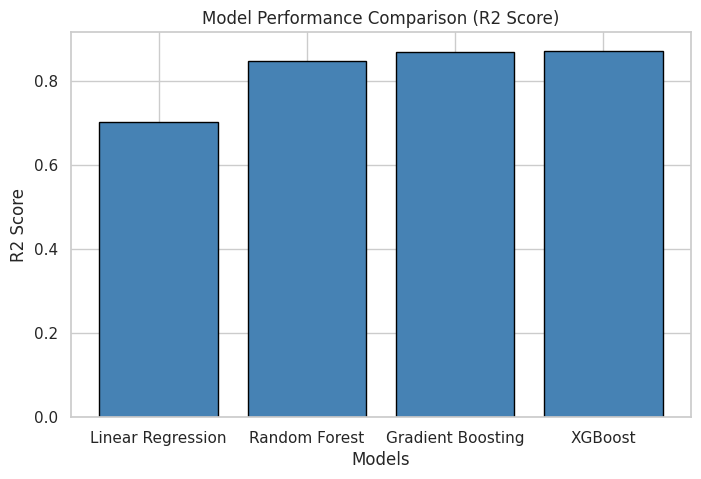

In [ ]:
models = ["Linear Regression","Random Forest","Gradient Boosting","XGBoost"]
r2_scores = [lr_r2, rf_r2, gb_r2, xgb_r2]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores, edgecolor="black", color="steelblue")

plt.title("Model Performance Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xlabel("Models")

plt.show()

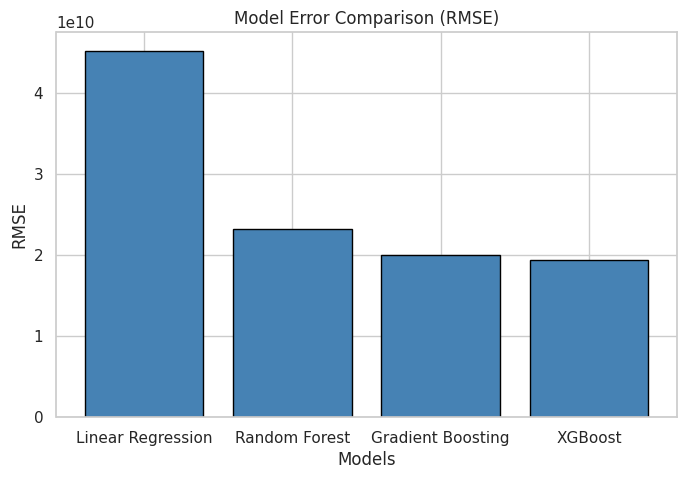

In [ ]:
rmse_scores = [lr_mse, rf_mse, gb_mse, xgb_mse]

plt.figure(figsize=(8,5))
plt.bar(models, rmse_scores, edgecolor="black", color="steelblue")

plt.title("Model Error Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Models")

plt.show()

As the results indicate, the XGBoost model achieved the best performance among all models. We now examine how its predicted values compare to the actual house prices.


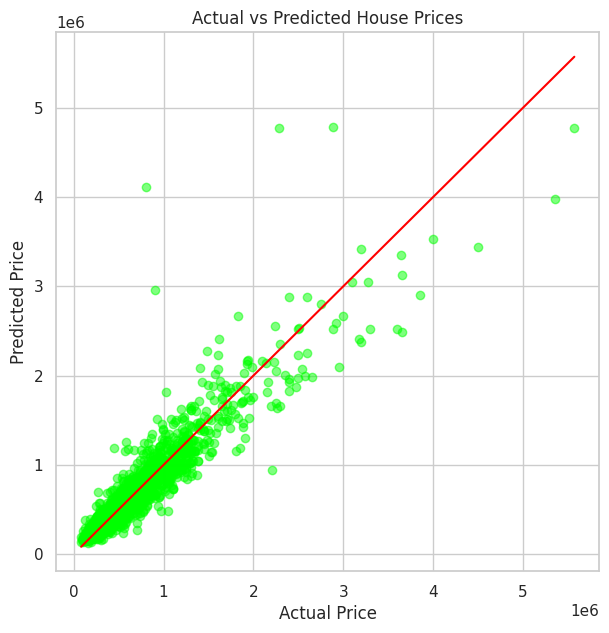

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_xgb, alpha=0.5, color="lime")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

A scatter plot is used to compare actual house prices with predicted values produced by the model.

If the model performs well, the data points should align closely with the diagonal reference line, indicating that predicted prices closely match the true values.

This visualization helps identify:

* prediction accuracy

* systematic biases

* extreme prediction errors

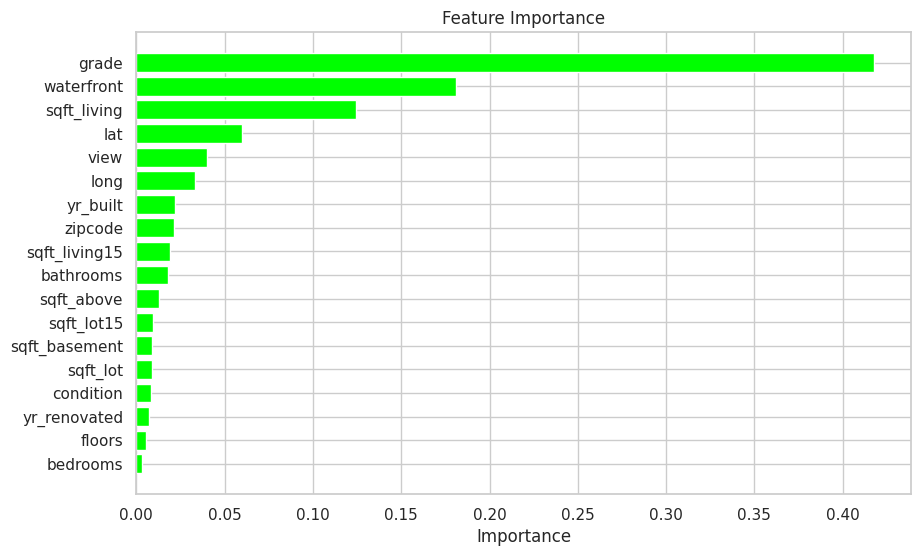

In [ ]:
importances = best_xgb.feature_importances_

features = X_train.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"], color="lime")

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

Feature importance analysis is used to determine which input variables contribute most to the model's predictions.

In the XGBoost model, feature importance scores quantify how frequently a feature is used in decision tree splits and how much it improves model performance.

This analysis provides valuable insight into which property attributes most strongly influence house prices, such as grade, waterfront, sqft_living and latitude had the most significant contribution.

Multiple machine learning models were evaluated for predicting house prices, including Linear Regression, Random Forest, Gradient Boosting, and XGBoost.

Among these models, XGBoost achieved the best performance, with the highest R2 score and the lowest prediction errors.

The results demonstrate that ensemble learning methods significantly outperform simple linear models for this dataset due to their ability to capture complex nonlinear relationships between housing features and price.